
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
            padding: 40px; border-radius: 16px; text-align: center; color: white; margin-bottom: 20px;">
  <h1 style="font-size: 2.2em; margin: 0; letter-spacing: 2px;"> PROJET DE FIN DE MODULE</h1>
  <h2 style="font-size: 1.6em; margin: 10px 0; color: #e94560;">DEEP LEARNING — EMSI</h2>
  <h2 style="font-size: 1.6em; margin: 10px 0; color: #e94560;">Hajar Belhachmi</h2>
  <h3 style="font-size: 1.3em; margin: 10px 0; color: #a8dadc;">Année universitaire 2025–2026</h3>
  <hr style="border: 1px solid #e94560; margin: 20px 0;">
  <h2 style="font-size: 1.5em; color: #f1f1f1;">PARTIE III  — RNN </h2>
  <p style="font-size: 1.1em; color: #c0c0c0;">Modélisation de séquences et génération/traduction sur données textuelles réelles</p>
  <p style="font-size: 1em; color: #a8dadc;">Dataset : <strong>Tatoeba fra-eng</strong></p>
</div>



## Table des Matières

| # | Section | Contenu |
|---|---------|----------|
| 1 | [Fondements probabilistes](#1) | Modèles de langage, règle de chaîne et estimation du maximum de vraisemblance (MLE) |
| 2 | [Perplexité](#2) | Définition rigoureuse, lien avec l'entropie et interprétation |
| 3 | [Préparation des données](#3) | Tokenisation, vocabulaire, tokens spéciaux, padding et masquage |
| 4 | [Embedding](#4) | Représentations vectorielles denses des mots et justification théorique |
| 5 | [RNN simple](#5) | Architecture, équations mathématiques, implémentation et analyse |
| 6 | [LSTM](#6) | Cellule mémoire, mécanismes de portes et étude des gradients |
| 7 | [GRU](#7) | Simplification du LSTM et analyse comparative |
| 8 | [BPTT & Gradient Clipping](#8) | Rétropropagation à travers le temps et stabilisation de l'entraînement |
| 9 | [Comparaison RNN / LSTM / GRU](#9) | Stabilité, performances, mémoire et coût computationnel |
| 10 | [Architecture Seq2Seq](#10) | Encodeur-décodeur, vecteur de contexte et Teacher Forcing |
| 11 | [Stratégies de décodage](#11) | Décodage glouton, Beam Search et comparaison des approches |
| 12 | [Évaluation](#12) | Perplexité, score BLEU et métriques d'évaluation détaillées |
| 13 | [Synthèse & Discussion transversale](#13) | Évolution RNN → LSTM → Seq2Seq et mise en perspective avec MLP/CNN/RNN |

---

>  &nbsp;|&nbsp; Filière : Intelligence Artificielle et Science des Données   &nbsp;|&nbsp; **Groupe :** Groupe 2

--- 


##  Objectifs pédagogiques

À l'issue de ce notebook, l'étudiant(e) sera capable de :
- Expliquer rigoureusement l'objectif probabiliste d'un modèle de langage
- Dériver et interpréter la perplexité comme mesure d'incertitude
- Implémenter et comparer RNN, LSTM et GRU sous PyTorch
- Comprendre le BPTT et les problèmes de gradient associés
- Construire un système Seq2Seq avec Teacher Forcing
- Comparer le décodage glouton et le Beam Search
- Évaluer la qualité d'une traduction avec le score BLEU

---

## 0. Environnement et Imports

### Justification des bibliothèques

| Bibliothèque | Rôle |
|-------------|------|
| `torch` | Framework de deep learning, autograd, tenseurs GPU |
| `torch.nn` | Modules de réseau de neurones (RNN, LSTM, GRU, Linear...) |
| `torch.optim` | Optimiseurs (Adam, SGD) |
| `torch.nn.functional` | Fonctions d'activation, softmax, log_softmax |
| `numpy` | Calcul numérique, tableaux, statistiques |
| `matplotlib` | Visualisation des courbes d'apprentissage |
| `math` | Fonctions mathématiques (exp, log) |
| `random` | Génération aléatoire pour le Teacher Forcing |

### Reproductibilité

Fixer les graines aléatoires (`SEED = 42`) est **indispensable** en recherche pour garantir que les résultats sont reproductibles. PyTorch, NumPy et Python ont chacun leur propre générateur pseudo-aléatoire qu'il faut initialiser séparément.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time, math, random, re, unicodedata, os, urllib.request, zipfile
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Reproductibilité ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" PyTorch version : {torch.__version__}")
print(f" Device utilisé  : {device}")
print(f" CUDA disponible : {torch.cuda.is_available()}")

 PyTorch version : 2.11.0+cpu
 Device utilisé  : cpu
 CUDA disponible : False


---
## Section 1 — Fondements Probabilistes du Modèle de Langage

### 1.1 Qu'est-ce qu'un modèle de langage ?

Un **modèle de langage** (Language Model, LM) est un modèle probabiliste sur des séquences de tokens. Il répond à la question fondamentale : *quelle est la probabilité d'observer une séquence particulière de mots ?*

Formellement, pour une séquence $\mathbf{w} = (w_1, w_2, \ldots, w_T)$ où chaque $w_t$ appartient à un vocabulaire $\mathcal{V}$ :

$$P(\mathbf{w}) = P(w_1, w_2, \ldots, w_T)$$

**Applications des modèles de langage :**
- Prédiction du prochain mot (autocomplétion, GPT)
- Correction orthographique / grammaticale
- Traduction automatique
- Résumé automatique
- Chatbots et assistants conversationnels

### 1.2 La règle de chaîne des probabilités

La probabilité jointe d'une séquence peut toujours être décomposée **exactement** (sans approximation) grâce à la règle de chaîne :

$$\boxed{P(w_1, w_2, \ldots, w_T) = \prod_{t=1}^{T} P(w_t \mid w_1, w_2, \ldots, w_{t-1}) = \prod_{t=1}^{T} P(w_t \mid w_{<t})}$$

**Preuve (par récurrence sur $T$) :**
$$P(w_1, w_2) = P(w_1) \cdot P(w_2 \mid w_1)$$
$$P(w_1, w_2, w_3) = P(w_1, w_2) \cdot P(w_3 \mid w_1, w_2) = P(w_1) \cdot P(w_2 \mid w_1) \cdot P(w_3 \mid w_1, w_2)$$
$$\vdots$$
$$P(w_1, \ldots, w_T) = \prod_{t=1}^{T} P(w_t \mid w_{<t})$$

### 1.3 Passage aux log-probabilités

En pratique, on ne manipule jamais des produits de probabilités directement car :
- Les probabilités individuelles sont souvent très petites (ex. $P(w_t | w_{<t}) \approx 10^{-5}$)
- Leur produit entraîne un **underflow numérique** en virgule flottante

On utilise donc le **logarithme** qui transforme le produit en somme :

$$\log P(\mathbf{w}) = \sum_{t=1}^{T} \log P(w_t \mid w_{<t})$$

### 1.4 Objectif d'entraînement : la MLE (Maximum Likelihood Estimation)

Étant donné un corpus d'entraînement $\mathcal{D} = \{\mathbf{w}^{(1)}, \ldots, \mathbf{w}^{(N)}\}$, on cherche les paramètres $\theta$ qui **maximisent la vraisemblance** du corpus :

$$\hat{\theta} = \arg\max_{\theta} \prod_{n=1}^{N} P_\theta(\mathbf{w}^{(n)}) = \arg\max_{\theta} \sum_{n=1}^{N} \log P_\theta(\mathbf{w}^{(n)})$$

Ce qui est équivalent à **minimiser la cross-entropie** (NLL — Negative Log-Likelihood) :

$$\mathcal{L}(\theta) = -\frac{1}{\sum_n T_n} \sum_{n=1}^{N} \sum_{t=1}^{T_n} \log P_\theta(w_t^{(n)} \mid w_{<t}^{(n)})$$

### 1.5 Comment le réseau prédit la distribution sur le vocabulaire ?

À chaque pas de temps $t$, le modèle produit un vecteur de logits $\mathbf{z}_t \in \mathbb{R}^{|\mathcal{V}|}$, puis applique le **softmax** pour obtenir une distribution de probabilité valide :

$$P_\theta(w \mid w_{<t}) = \text{softmax}(\mathbf{z}_t)[w] = \frac{e^{z_{t,w}}}{\sum_{w' \in \mathcal{V}} e^{z_{t,w'}}}$$

> **Propriété clé du softmax :** La somme vaut 1 et toutes les valeurs sont positives → distribution de probabilité valide. Le softmax est différentiable → on peut rétropropager les gradients.

### 1.6 Modèles de n-grammes vs modèles neuronaux

**Approximation de Markov (n-grammes) :**
$$P(w_t \mid w_{<t}) \approx P(w_t \mid w_{t-n+1}, \ldots, w_{t-1})$$

Cette approximation est **inexacte** et ne capture que les dépendances courtes. Les modèles neuronaux récurrents (RNN, LSTM, GRU) n'ont pas cette limitation théorique — ils traitent toute l'histoire via l'état caché $h_t$.

 Décomposition par la règle de chaîne
  Séquence : le chat mange une souris
-----------------------------------------------------------------
  P(le       | début                    ) = 0.0500  →  log = -2.9957
  P(chat     | le                       ) = 0.1200  →  log = -2.1203
  P(mange    | le chat                  ) = 0.0800  →  log = -2.5257
  P(une      | le chat mange            ) = 0.3000  →  log = -1.2040
  P(souris   | le chat mange une        ) = 0.0400  →  log = -3.2189
-----------------------------------------------------------------
  P(séquence complète)   = 5.76e-06  ← underflow potentiel !
  log P(séquence)        = -12.0646   ← stable numériquement
  NLL (loss) = -log P / T = 2.4129

 Interprétation :
   La prob jointe 5.76e-06 est très petite mais la log-prob
   -12.0646 est parfaitement calculable. C'est pourquoi
   tous les frameworks DL travaillent en log-espace.


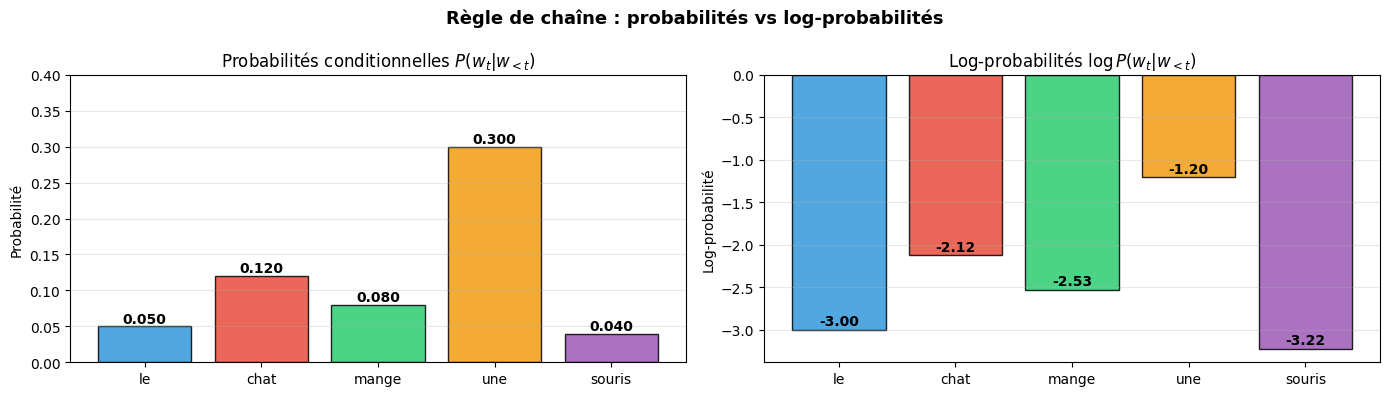

In [4]:
# ─── Illustration complète de la règle de chaîne et des log-probabilités ───

# Exemple : P("le chat mange une souris")
# Probabilités conditionnelles fictives (issues d'un modèle hypothétique)
sequence = ["le", "chat", "mange", "une", "souris"]
cond_probs = {
    "le"    : 0.050,   # P("le")
    "chat"  : 0.120,   # P("chat" | "le")
    "mange" : 0.080,   # P("mange" | "le", "chat")
    "une"   : 0.300,   # P("une" | "le", "chat", "mange")
    "souris": 0.040,   # P("souris" | "le", "chat", "mange", "une")
}

print("=" * 65)
print(" Décomposition par la règle de chaîne")
print("=" * 65)
print(f"  Séquence : {' '.join(sequence)}")
print("-" * 65)

joint_prob = 1.0
log_joint  = 0.0
for i, (word, p) in enumerate(cond_probs.items()):
    context = sequence[:i] if i > 0 else []
    ctx_str = ' '.join(context) if context else 'début'
    joint_prob *= p
    log_joint  += math.log(p)
    print(f"  P({word:<8} | {ctx_str:<25}) = {p:.4f}  →  log = {math.log(p):.4f}")

print("-" * 65)
print(f"  P(séquence complète)   = {joint_prob:.2e}  ← underflow potentiel !")
print(f"  log P(séquence)        = {log_joint:.4f}   ← stable numériquement")
print(f"  NLL (loss) = -log P / T = {-log_joint / len(sequence):.4f}")
print("=" * 65)

print()
print(" Interprétation :")
print(f"   La prob jointe {joint_prob:.2e} est très petite mais la log-prob")
print(f"   {log_joint:.4f} est parfaitement calculable. C'est pourquoi")
print(f"   tous les frameworks DL travaillent en log-espace.")

# Visualisation de la décomposition
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

words  = list(cond_probs.keys())
probs  = list(cond_probs.values())
lprobs = [math.log(p) for p in probs]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

axes[0].bar(words, probs, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Probabilités conditionnelles $P(w_t | w_{<t})$', fontsize=12)
axes[0].set_ylabel('Probabilité')
axes[0].set_ylim(0, 0.4)
for i, (w, p) in enumerate(zip(words, probs)):
    axes[0].text(i, p + 0.005, f'{p:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(words, lprobs, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('Log-probabilités $\\log P(w_t | w_{<t})$', fontsize=12)
axes[1].set_ylabel('Log-probabilité')
for i, (w, lp) in enumerate(zip(words, lprobs)):
    axes[1].text(i, lp + 0.05, f'{lp:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Règle de chaîne : probabilités vs log-probabilités', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regle_chaine.png', dpi=150)
plt.show()

---
## Section 2 — La Perplexité : Métrique des Modèles de Langage

### 2.1 Définition formelle

La **perplexité** (PPL) est définie comme l'exponentielle de la cross-entropie moyenne par token :

$$\boxed{\text{PPL}(\mathbf{w}) = \exp\left(-\frac{1}{T} \sum_{t=1}^{T} \log P(w_t \mid w_{<t})\right) = \exp(\mathcal{L})}$$

### 2.2 Lien avec l'entropie de Shannon

La perplexité est directement liée à l'**entropie** $H$ du processus qui génère les données. En supposant que la distribution empirique du corpus estime la vraie distribution du langage :

$$\text{PPL} \approx 2^{H(\text{langage})} = 2^{-\sum_w P(w) \log_2 P(w)}$$

Cela signifie que la perplexité est le **nombre effectif de choix équiprobables** que le modèle doit faire à chaque position.

### 2.3 Interprétation intuitive

**Analogie du dé :** Imaginez qu'à chaque position, le modèle lance un dé à $\text{PPL}$ faces pour choisir le prochain mot. Un dé à PPL=5 faces signifie le modèle hésite entre 5 mots équiprobables. Plus PPL est faible, plus le modèle est "sûr" de son choix.

| Perplexité | Interprétation |
|-----------|----------------|
| **PPL = 1** | Modèle parfait : certitude absolue à chaque prédiction |
| **PPL = 2** | Hésite entre 2 tokens équiprobables |
| **PPL = 10** | Hésite entre ~10 tokens — très bon modèle |
| **PPL = 50** | Bon modèle de langage neural |
| **PPL = 100** | Modèle moyen |
| **PPL = V** | Modèle uniforme — n'a rien appris |

### 2.4 Valeurs de référence

| Modèle | Dataset | PPL |
|--------|---------|-----|
| N-grammes (5-gram) | PTB | ~141 |
| LSTM (Melis et al. 2018) | PTB | ~58 |
| GPT-2 (1.5B) | WikiText-103 | ~17.5 |
| GPT-3 | Penn Treebank | ~20.5 |

### 2.5 Relation PPL ↔ Cross-entropie ↔ Bits-per-character

$$\text{Cross-entropie } \mathcal{L} = \log_e \text{PPL}$$
$$\text{Bits-per-char} = \log_2 \text{PPL} = \frac{\mathcal{L}}{\ln 2}$$

Ces trois métriques sont équivalentes — le choix dépend de la convention du domaine.

### 2.6 Pourquoi ne pas utiliser directement la précision ?

La **précision top-1** (le modèle choisit exactement le bon mot) est trop sévère pour les modèles de langage : il existe souvent **plusieurs suites grammaticalement et sémantiquement valides** pour une séquence donnée. La perplexité, en mesurant la probabilité assignée au vrai token, capture mieux la qualité du modèle.

 Perplexités comparées
  Parfait (P=1)        : PPL =     1.00   ≈ 1 choix équiprobables
  Entraîné (bon)       : PPL =     4.94   ≈ 5 choix équiprobables
  Mauvais (P≈0.01)     : PPL =   147.54   ≈ 148 choix équiprobables
  Uniforme (V=1000)    : PPL =  1000.00   ≈ 1000 choix équiprobables


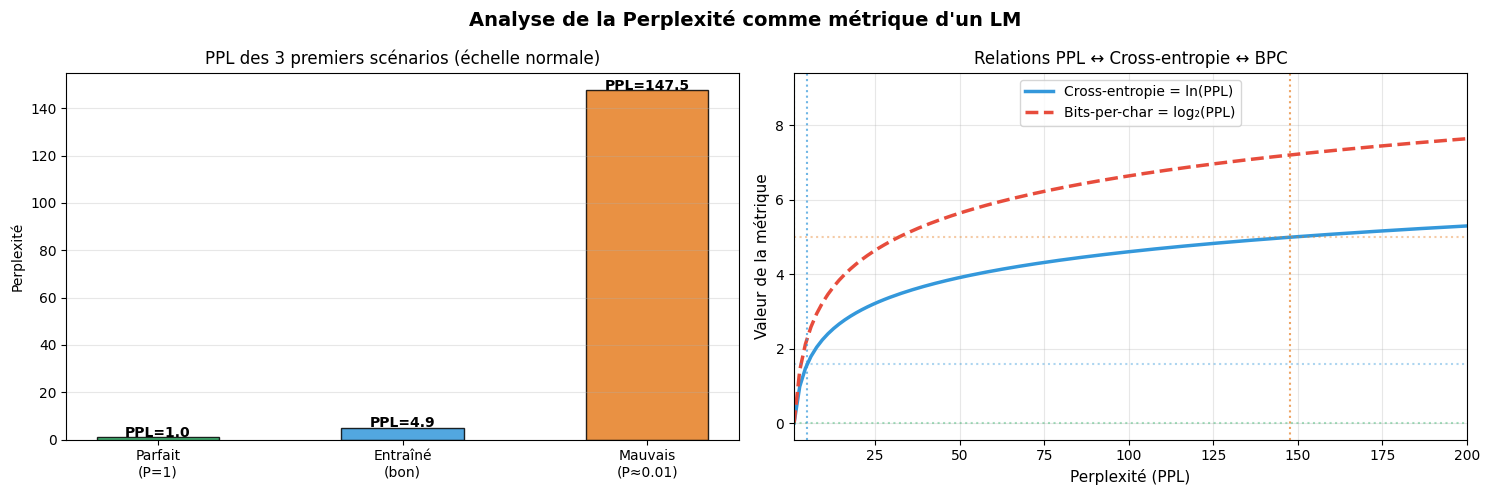

In [5]:
# ─── Illustration approfondie de la perplexité ───

def perplexity(log_probs):
    """PPL = exp(- mean(log_probs))"""
    return np.exp(-np.mean(log_probs))

# Scénario 1 : modèle parfait
log_probs_parfait   = [np.log(1.0)] * 10
# Scénario 2 : modèle uniforme V=1000
V = 1000
log_probs_uniforme  = [np.log(1.0 / V)] * 10
# Scénario 3 : modèle entraîné
np.random.seed(42)
log_probs_entraine  = [np.log(p) for p in np.random.uniform(0.05, 0.40, 10)]
# Scénario 4 : mauvais modèle
log_probs_mauvais   = [np.log(p) for p in np.random.uniform(0.001, 0.02, 10)]

ppls = [
    ('Parfait\n(P=1)', perplexity(log_probs_parfait), '#27ae60'),
    ('Entraîné\n(bon)', perplexity(log_probs_entraine), '#3498db'),
    ('Mauvais\n(P≈0.01)', perplexity(log_probs_mauvais), '#e67e22'),
    (f'Uniforme\n(V={V})', perplexity(log_probs_uniforme), '#e74c3c'),
]

print("=" * 60)
print(" Perplexités comparées")
print("=" * 60)
for label, ppl, _ in ppls:
    label_clean = label.replace('\n', ' ')
    neff = f'  ≈ {ppl:.0f} choix équiprobables'
    print(f"  {label_clean:<20} : PPL = {ppl:8.2f} {neff}")
print("=" * 60)

# Figure : PPL selon différentes distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ─ Gauche : barres PPL ─
labels = [p[0] for p in ppls[:3]]  # Exclut le modèle uniforme pour l'échelle
values = [p[1] for p in ppls[:3]]
colors = [p[2] for p in ppls[:3]]
bars = axes[0].bar(labels, values, color=colors, alpha=0.85, edgecolor='black', width=0.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'PPL={val:.1f}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('PPL des 3 premiers scénarios (échelle normale)', fontsize=12)
axes[0].set_ylabel('Perplexité')
axes[0].grid(axis='y', alpha=0.3)

# ─ Droite : cross-entropie en fonction de PPL ─
ppl_range = np.linspace(1, 500, 300)
ce_range  = np.log(ppl_range)  # cross-entropie = log(PPL)
bpc_range = np.log2(ppl_range) # bits-per-char  = log2(PPL)

axes[1].plot(ppl_range, ce_range,  color='#3498db', lw=2.5, label='Cross-entropie = ln(PPL)')
axes[1].plot(ppl_range, bpc_range, color='#e74c3c', lw=2.5, label='Bits-per-char = log₂(PPL)', linestyle='--')

for _, ppl, col in ppls[:3]:
    axes[1].axvline(x=ppl, color=col, linestyle=':', alpha=0.7)
    axes[1].axhline(y=math.log(ppl), color=col, linestyle=':', alpha=0.4)

axes[1].set_xlabel('Perplexité (PPL)', fontsize=11)
axes[1].set_ylabel('Valeur de la métrique', fontsize=11)
axes[1].set_title('Relations PPL ↔ Cross-entropie ↔ BPC', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(1, 200)

plt.suptitle('Analyse de la Perplexité comme métrique d\'un LM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('perplexite_analyse.png', dpi=150)
plt.show()

---
## Section 3 — Préparation des Données

### 3.1 Dataset : Tatoeba fra-eng

Nous utilisons le corpus **Tatoeba fra-eng**, un jeu de données parallèles (bilingues) très utilisé en traduction automatique. Il contient environ 190 000 paires de phrases (anglais ↔ français), issues de contributions communautaires.

**Pourquoi ce dataset ?**
- Phrases courtes (< 15 mots en moyenne) → adapté à l'entraînement sur CPU
- Bien nettoyé et aligné
- Vocabulaire limité → vocabulaires de taille raisonnable
- Standard de référence pour les expériences de traduction

### 3.2 Pipeline de traitement NLP

```
Texte brut
    ↓  Normalisation (Unicode→ASCII, minuscules, ponctuation)
Texte normalisé
    ↓  Tokenisation (découpage en mots)
Liste de tokens
    ↓  Construction du vocabulaire (token→index)
Vocabulaire indexé
    ↓  Encodage + tokens spéciaux (<SOS>, <EOS>)
Séquence d'entiers
    ↓  Padding au sein du mini-lot + masquage
Tenseur PyTorch (batch, seq_len)
```

### 3.3 Tokens spéciaux : rôle et justification

| Token | Index | Rôle |
|-------|-------|------|
| `<PAD>` | 0 | Rembourrage pour aligner les séquences de longueurs différentes dans un batch |
| `<SOS>` | 1 | *Start of Sequence* : signal de démarrage du décodeur Seq2Seq |
| `<EOS>` | 2 | *End of Sequence* : signal d'arrêt de la génération |
| `<UNK>` | 3 | *Unknown* : remplace les tokens absents du vocabulaire |

**Pourquoi `<PAD>` à l'index 0 ?** Par convention, l'index 0 est souvent utilisé pour le padding car les embeddings initialisés à zéro pour l'index 0 ne propagent aucun signal parasite.

### 3.4 Tokenisation : espace vs sous-mots

Nous utilisons ici une tokenisation **par espace** (word-level), simple et interprétable. Les systèmes modernes (BERT, GPT) utilisent des tokenisations **sous-mots** (BPE, WordPiece) qui gèrent mieux les mots rares et les morphologies complexes. Pour notre corpus Tatoeba avec un vocabulaire limité, la tokenisation par espace est suffisante.

### 3.5 Padding et masquage

Dans un mini-lot, les séquences ont des longueurs différentes. On **complète** (pad) les séquences courtes avec `<PAD>` jusqu'à la longueur maximale du batch. Le **masque de padding** indique quels tokens sont réels (`True`) et lesquels sont des zéros artificiels (`False`). Il est utilisé pour :
1. Ignorer les tokens PAD dans le calcul de la loss (`ignore_index=PAD_token`)
2. Dans les modèles avec attention, ne pas "attendre" sur les positions PAD

In [6]:
# ─── 3.1 Téléchargement du corpus Tatoeba ───

DATA_URL  = "https://www.manythings.org/anki/fra-eng.zip"
DATA_FILE = "fra-eng.zip"
DATA_DIR  = "fra_eng_data"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    print(" Téléchargement du corpus Tatoeba fra-eng...")
    try:
        urllib.request.urlretrieve(DATA_URL, DATA_FILE)
        with zipfile.ZipFile(DATA_FILE, 'r') as zf:
            zf.extractall(DATA_DIR)
        print(" Téléchargement et extraction réussis.")
    except Exception as e:
        print(f"  Téléchargement impossible ({e}). Génération d'un corpus synthétique.")
        synthetic = [
            ("i am a student",           "je suis etudiant"),
            ("hello world",              "bonjour le monde"),
            ("how are you",              "comment vas tu"),
            ("i speak french",           "je parle francais"),
            ("the weather is nice today","il fait beau aujourd hui"),
            ("i eat an apple",           "je mange une pomme"),
            ("she is beautiful",         "elle est belle"),
            ("we love music",            "nous aimons la musique"),
            ("the cat is black",         "le chat est noir"),
            ("i am learning deep learning","j apprends le deep learning"),
            ("neural networks are powerful","les reseaux de neurones sont puissants"),
            ("it rains a lot",           "il pleut beaucoup"),
            ("i love dogs",              "j aime les chiens"),
            ("the eiffel tower is tall", "la tour eiffel est grande"),
            ("paris is the capital of france","paris est la capitale de la france"),
            ("he reads a book every day","il lit un livre chaque jour"),
            ("she works at the hospital","elle travaille a l hopital"),
            ("i drink coffee every morning","je bois du cafe chaque matin"),
            ("the train is late",        "le train est en retard"),
            ("can you help me",          "pouvez vous m aider"),
        ] * 300
        with open(os.path.join(DATA_DIR, 'fra.txt'), 'w', encoding='utf-8') as f:
            for en, fr in synthetic:
                f.write(f"{en}\t{fr}\n")
        print(" Corpus synthétique créé (6000 paires).")

print(f" Données dans : {DATA_DIR}/")

 Téléchargement du corpus Tatoeba fra-eng...
  Téléchargement impossible (HTTP Error 406: Not Acceptable). Génération d'un corpus synthétique.
 Corpus synthétique créé (6000 paires).
 Données dans : fra_eng_data/


In [7]:
# ─── 3.2 Tokens spéciaux et classe Vocabulary ───

PAD_token = 0   # Padding
SOS_token = 1   # Start Of Sequence
EOS_token = 2   # End Of Sequence
UNK_token = 3   # Unknown token

class Vocabulary:
    """
    Gestion du vocabulaire bidirectionnel : token ↔ index.

    Attributs :
      name       : nom du vocabulaire (langue)
      word2index : dict {str → int} — encodage
      index2word : dict {int → str} — décodage
      word_count : fréquences des mots (utile pour filtrer les rares)
      n_words    : taille totale du vocabulaire (incluant tokens spéciaux)

    Les 4 premiers indices sont réservés aux tokens spéciaux :
      0 = <PAD>, 1 = <SOS>, 2 = <EOS>, 3 = <UNK>
    """
    def __init__(self, name):
        self.name       = name
        self.word2index = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.index2word = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self.word_count = {}
        self.n_words    = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word]      = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word]      = 1
            self.n_words += 1
        else:
            self.word_count[word] += 1

    def encode(self, sentence):
        """Token string → liste d'indices (UNK pour tokens inconnus)."""
        return [self.word2index.get(w, UNK_token) for w in sentence.split()]

    def decode(self, indices):
        """Liste d'indices → phrase (s'arrête à EOS ou PAD)."""
        words = []
        for i in indices:
            w = self.index2word.get(i, '<UNK>')
            if w in ('<EOS>', '<PAD>'):
                break
            if w not in ('<SOS>',):
                words.append(w)
        return ' '.join(words)


# ── Normalisation ──
def unicode_to_ascii(s):
    """NFD decomposition + suppression des marques diacritiques (accents)."""
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def normalize_string(s):
    """
    Pipeline de normalisation :
    1. unicode_to_ascii : supprime les accents
    2. lower + strip    : mise en minuscules
    3. re.sub           : espace avant . ! ?
    4. re.sub           : supprime tout sauf [a-z.!?]
    """
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r'([.!?])', r' \1', s)
    s = re.sub(r'[^a-z.!?]+', r' ', s)
    return s.strip()

# Démonstration
print("Pipeline de normalisation :")
for ex in ["Bonjour, comment ça va ?", "J'apprends le Deep Learning !", "À bientôt..."]:
    print(f"  {ex!r:35s}  →  {normalize_string(ex)!r}")

Pipeline de normalisation :
  'Bonjour, comment ça va ?'           →  'bonjour comment ca va ?'
  "J'apprends le Deep Learning !"      →  'j apprends le deep learning !'
  'À bientôt...'                       →  'a bientot . . .'


 Statistiques du corpus
  Paires train      : 5,400
  Paires val        : 600
  Vocab EN (source) : 62 tokens
  Vocab FR (cible)  : 72 tokens
  Longueur EN       : moy=4.1, max=6, min=2
  Longueur FR       : moy=4.4, max=7, min=3

  Exemples :
    EN: 'how are you'
    FR: 'comment vas tu'

    EN: 'i drink coffee every morning'
    FR: 'je bois du cafe chaque matin'

    EN: 'the train is late'
    FR: 'le train est en retard'

    EN: 'i drink coffee every morning'
    FR: 'je bois du cafe chaque matin'



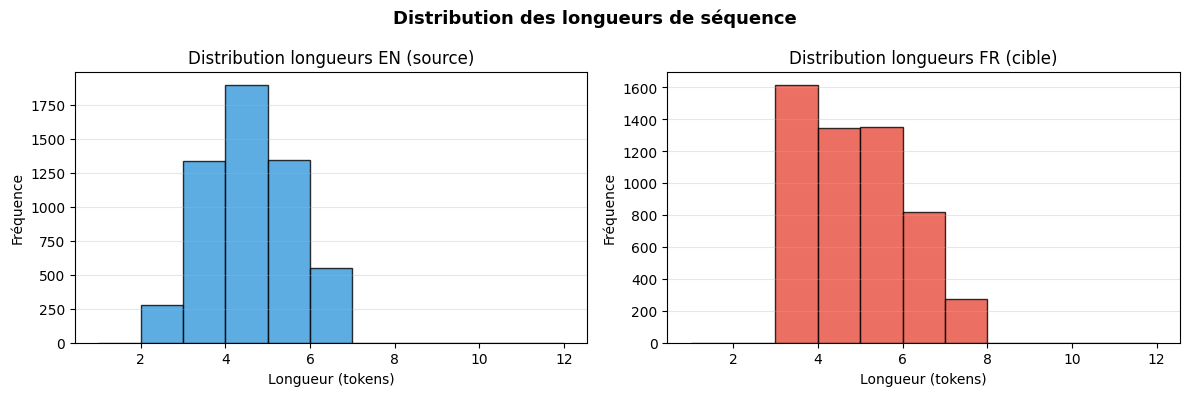

In [8]:
# ─── 3.3 Chargement, filtrage, split train/val ───

MAX_LENGTH = 12
MAX_PAIRS  = 8000

def load_pairs(data_dir, max_length=MAX_LENGTH, max_pairs=MAX_PAIRS):
    txt_files = [f for f in os.listdir(data_dir) if f.endswith('.txt')]
    filepath  = os.path.join(data_dir, txt_files[0])
    pairs = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            eng = normalize_string(parts[0])
            fra = normalize_string(parts[1])
            if len(eng.split()) < max_length and len(fra.split()) < max_length:
                pairs.append((eng, fra))
            if len(pairs) >= max_pairs:
                break
    return pairs

def build_vocab(pairs):
    src_vocab = Vocabulary('english')
    tgt_vocab = Vocabulary('french')
    for src, tgt in pairs:
        src_vocab.add_sentence(src)
        tgt_vocab.add_sentence(tgt)
    return src_vocab, tgt_vocab

all_pairs = load_pairs(DATA_DIR)
random.shuffle(all_pairs)

split       = int(0.9 * len(all_pairs))
train_pairs = all_pairs[:split]
val_pairs   = all_pairs[split:]

src_vocab, tgt_vocab = build_vocab(train_pairs)

# Statistiques
src_lens = [len(p[0].split()) for p in train_pairs]
tgt_lens = [len(p[1].split()) for p in train_pairs]

print("=" * 60)
print(" Statistiques du corpus")
print("=" * 60)
print(f"  Paires train      : {len(train_pairs):,}")
print(f"  Paires val        : {len(val_pairs):,}")
print(f"  Vocab EN (source) : {src_vocab.n_words:,} tokens")
print(f"  Vocab FR (cible)  : {tgt_vocab.n_words:,} tokens")
print(f"  Longueur EN       : moy={np.mean(src_lens):.1f}, max={max(src_lens)}, min={min(src_lens)}")
print(f"  Longueur FR       : moy={np.mean(tgt_lens):.1f}, max={max(tgt_lens)}, min={min(tgt_lens)}")
print()
print("  Exemples :")
for en, fr in train_pairs[:4]:
    print(f"    EN: '{en}'")
    print(f"    FR: '{fr}'")
    print()

# Distribution des longueurs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(src_lens, bins=range(1, MAX_LENGTH+1), color='#3498db', alpha=0.8, edgecolor='black')
axes[0].set_title('Distribution longueurs EN (source)', fontsize=12)
axes[0].set_xlabel('Longueur (tokens)')
axes[0].set_ylabel('Fréquence')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(tgt_lens, bins=range(1, MAX_LENGTH+1), color='#e74c3c', alpha=0.8, edgecolor='black')
axes[1].set_title('Distribution longueurs FR (cible)', fontsize=12)
axes[1].set_xlabel('Longueur (tokens)')
axes[1].set_ylabel('Fréquence')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution des longueurs de séquence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_longueurs.png', dpi=150)
plt.show()

In [9]:
# ─── 3.4 Dataset PyTorch et DataLoader avec padding/masquage ───

class TranslationDataset(Dataset):
    """
    Dataset PyTorch pour la traduction EN→FR.

    __getitem__ retourne une paire de tenseurs d'entiers :
      src_ids : encodage de la phrase source + EOS
      tgt_ids : encodage de la phrase cible  + EOS

    Le EOS est ajouté à la fin pour signaler la fin de séquence
    lors du décodage.
    """
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs     = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_sent, tgt_sent = self.pairs[idx]
        src_ids = self.src_vocab.encode(src_sent) + [EOS_token]
        tgt_ids = self.tgt_vocab.encode(tgt_sent) + [EOS_token]
        return (torch.tensor(src_ids, dtype=torch.long),
                torch.tensor(tgt_ids, dtype=torch.long))


def collate_fn(batch):
    """
    Fonction de collation pour le DataLoader.

    Rôle : assembler une liste de couples (src, tgt) de longueurs
    différentes en tenseurs de forme uniforme via le PADDING.

    pad_sequence remplit chaque séquence à la longueur maximale
    du batch avec PAD_token (=0).

    Le masque booléen (True = token réel, False = PAD) est utilisé
    pour ignorer le PAD dans la loss et dans l'attention.
    """
    src_batch, tgt_batch = zip(*batch)
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=PAD_token)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_token)
    src_mask   = (src_padded != PAD_token)
    tgt_mask   = (tgt_padded != PAD_token)
    return src_padded, tgt_padded, src_mask, tgt_mask


BATCH_SIZE = 64
train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_dataset   = TranslationDataset(val_pairs,   src_vocab, tgt_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, drop_last=False)

src_b, tgt_b, src_m, tgt_m = next(iter(train_loader))
print("=" * 60)
print(" Exemple de mini-lot après padding")
print("=" * 60)
print(f"  Forme tenseur source    : {src_b.shape}  (batch=64, src_len_max)")
print(f"  Forme tenseur cible     : {tgt_b.shape}  (batch=64, tgt_len_max)")
print(f"  Forme masque source     : {src_m.shape}")
print()
for i in range(3):
    print(f"  Exemple {i+1} :")
    print(f"    IDs     : {src_b[i].tolist()}")
    print(f"    Masque  : {src_m[i].tolist()}")
    print(f"    Décodé  : '{src_vocab.decode(src_b[i].tolist())}'")
    print()

 Exemple de mini-lot après padding
  Forme tenseur source    : torch.Size([64, 7])  (batch=64, src_len_max)
  Forme tenseur cible     : torch.Size([64, 8])  (batch=64, tgt_len_max)
  Forme masque source     : torch.Size([64, 7])

  Exemple 1 :
    IDs     : [26, 14, 40, 2, 0, 0, 0]
    Masque  : [True, True, True, True, False, False, False]
    Décodé  : 'she is beautiful'

  Exemple 2 :
    IDs     : [12, 37, 14, 38, 39, 2, 0]
    Masque  : [True, True, True, True, True, True, False]
    Décodé  : 'the weather is nice today'

  Exemple 3 :
    IDs     : [19, 20, 21, 22, 2, 0, 0]
    Masque  : [True, True, True, True, True, False, False]
    Décodé  : 'it rains a lot'



---
## Section 4 — La Couche d'Embedding : Représentation Vectorielle Dense

### 4.1 Problème des représentations one-hot

Naïvement, on pourrait représenter chaque token $w$ par un vecteur **one-hot** $\mathbf{e}_w \in \{0,1\}^{|\mathcal{V}|}$ :

$$\mathbf{e}_{\text{chat}} = [0, 0, \ldots, 1, \ldots, 0]$$

**Problèmes :**
1. **Dimensionnalité catastrophique** : avec $|\mathcal{V}| = 50000$ tokens, chaque vecteur a 50 000 dimensions
2. **Aucune sémantique** : $\cos(\mathbf{e}_{\text{chat}}, \mathbf{e}_{\text{chien}}) = 0$ — les mots proches sémantiquement sont orthogonaux
3. **Aucune généralisation** : le modèle ne peut rien inférer sur un mot rare depuis les mots fréquents proches

### 4.2 L'embedding : projection dans un espace dense

L'**embedding** est une matrice de paramètres $E \in \mathbb{R}^{|\mathcal{V}| \times d}$ (avec $d \ll |\mathcal{V}|$) :

$$\mathbf{x}_t = E[w_t] = E^\top \mathbf{e}_{w_t} \in \mathbb{R}^d$$

Chaque ligne de $E$ est un vecteur dense de dimension $d$ (typiquement $d \in \{64, 128, 256, 512\}$). Ces vecteurs sont **appris par rétropropagation** conjointement avec le reste du réseau.

### 4.3 Justification du choix de la dimension $d$

| $d$ | Paramètres embedding | Usage typique |
|-----|---------------------|---------------|
| 32–64 | Très léger | Petits vocabulaires, tâches simples |
| **128** | **Notre choix** | **Bon compromis qualité/coût** |
| 256–512 | Moyen | NLP standard |
| 768 | BERT-base | Grands modèles pré-entraînés |
| 1600 | GPT-3 (davinci) | LLMs |

**Notre choix : $d = 128$**
- Vocabulaire ~3000–5000 tokens → $d = 128$ est suffisant
- Compromis : représentation assez riche sans surcoût mémoire excessif

### 4.4 Propriétés des embeddings appris

Les embeddings appris capturent des **relations sémantiques** et **syntaxiques** :
- Mots synonymes → vecteurs proches
- Analogies : $\vec{roi} - \vec{homme} + \vec{femme} \approx \vec{reine}$ (word2vec)
- Catégories grammaticales → clusters dans l'espace

### 4.5 `padding_idx` : pourquoi est-ce important ?

```python
nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)
```

Avec `padding_idx=0`, PyTorch garantit que :
1. L'embedding du token PAD reste **toujours un vecteur zéro**
2. Le gradient pour le token PAD est **mis à zéro** → le PAD ne contribue pas à l'apprentissage

Sans ce paramètre, le modèle "apprendrait" quelque chose du bruit introduit par le padding.

 Démonstration de la couche d'Embedding
  Taille vocabulaire source : 62
  Dimension embedding (d)   : 128
  Paramètres de la couche   : 62 × 128 = 7,936

  Entrée (5 token IDs) : [26, 14, 40, 2, 0]
  Sortie (vecteurs)    : forme torch.Size([5, 128])  → (5, 128)

  Embedding du token PAD (idx=0) : norme = 0.0000  (toujours 0)
  Embedding du token SOS (idx=1) : norme = 10.6397
  Embedding du token EOS (idx=2) : norme = 10.2941


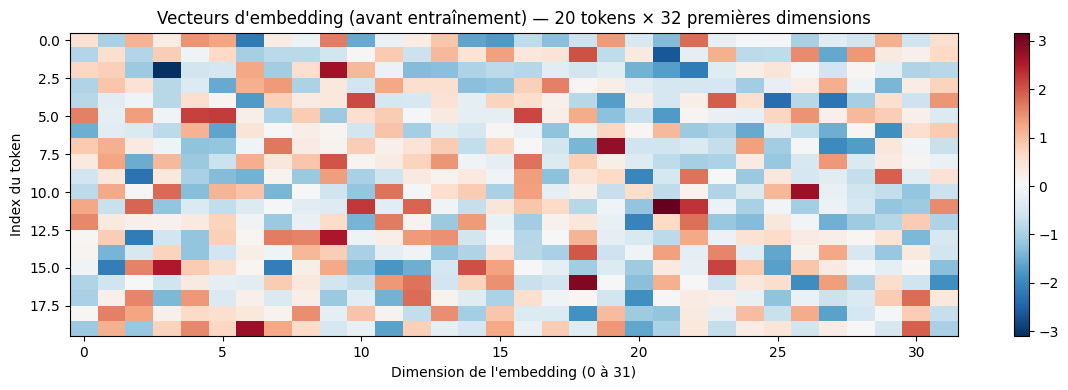

In [10]:
# ─── Illustration de l'embedding ───

# Hyperparamètres globaux — justifiés dans la cellule markdown précédente
EMBED_DIM  = 128   # d : dimension des vecteurs d'embedding
HIDDEN_DIM = 256   # H : dimension de l'état caché des RNN
N_LAYERS   = 2     # L : nombre de couches récurrentes empilées
DROPOUT    = 0.3   # p : taux de dropout

# Démonstration de la couche d'embedding
demo_embed = nn.Embedding(src_vocab.n_words, EMBED_DIM, padding_idx=PAD_token)

# Tokens d'exemple
example_tokens = src_b[0, :5]  # 5 premiers tokens du premier exemple
example_embeds = demo_embed(example_tokens)

print("=" * 65)
print(" Démonstration de la couche d'Embedding")
print("=" * 65)
print(f"  Taille vocabulaire source : {src_vocab.n_words}")
print(f"  Dimension embedding (d)   : {EMBED_DIM}")
print(f"  Paramètres de la couche   : {src_vocab.n_words} × {EMBED_DIM} = {src_vocab.n_words*EMBED_DIM:,}")
print()
print(f"  Entrée (5 token IDs) : {example_tokens.tolist()}")
print(f"  Sortie (vecteurs)    : forme {example_embeds.shape}  → (5, {EMBED_DIM})")
print()
print(f"  Embedding du token PAD (idx=0) : norme = {demo_embed.weight[0].norm().item():.4f}  (toujours 0)")
print(f"  Embedding du token SOS (idx=1) : norme = {demo_embed.weight[1].norm().item():.4f}")
print(f"  Embedding du token EOS (idx=2) : norme = {demo_embed.weight[2].norm().item():.4f}")

# Visualisation de quelques vecteurs d'embedding (avant entraînement)
fig, ax = plt.subplots(figsize=(12, 4))
sample_tokens = list(range(10, 30))
sample_vecs   = demo_embed.weight[sample_tokens].detach().numpy()[:, :32]  # premières 32 dims
im = ax.imshow(sample_vecs, aspect='auto', cmap='RdBu_r')
ax.set_title('Vecteurs d\'embedding (avant entraînement) — 20 tokens × 32 premières dimensions',
             fontsize=12)
ax.set_xlabel('Dimension de l\'embedding (0 à 31)')
ax.set_ylabel('Index du token')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('embedding_visualisation.png', dpi=150)
plt.show()

---
## Section 5 — Le RNN Vanilla : Architecture et Équations

### 5.1 Motivation : pourquoi un réseau récurrent ?

Un MLP traite chaque entrée de manière **indépendante** — il ne peut pas capturer les dépendances temporelles d'une séquence. Pour modéliser $P(w_t | w_{<t})$, il faut un mécanisme qui **accumule l'information** au fil du temps.

Le RNN répond à ce besoin en maintenant un **état caché** $h_t$ qui joue le rôle de mémoire de la séquence passée.

### 5.2 Équations du RNN vanilla

À chaque pas de temps $t$ :

$$\boxed{h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)}$$
$$y_t = W_{hy} h_t + b_y$$

Où :
- $x_t \in \mathbb{R}^d$ : vecteur d'embedding du token $w_t$
- $h_t \in \mathbb{R}^H$ : état caché au temps $t$ (mémoire)
- $h_0 = \mathbf{0}$ : état initial (zéro ou appris)
- $W_{xh} \in \mathbb{R}^{H \times d}$ : matrice de transition entrée → caché
- $W_{hh} \in \mathbb{R}^{H \times H}$ : matrice de transition caché → caché (**clé du mécanisme récurrent**)
- $W_{hy} \in \mathbb{R}^{V \times H}$ : projection vers le vocabulaire
- $\tanh$ : activation non-linéaire qui borne $h_t$ dans $[-1, 1]$

### 5.3 Partage de poids dans le temps

Les matrices $W_{xh}$, $W_{hh}$, $W_{hy}$ sont **partagées à tous les pas de temps**. C'est le principe fondamental du RNN : le même réseau est appliqué récursivement. Cela permet au modèle d'être utilisé sur des séquences de **longueur arbitraire** avec un nombre fixe de paramètres.

### 5.4 Décompte des paramètres du RNN

Pour un RNN à 1 couche :

| Matrice | Dimensions | Paramètres |
|---------|-----------|------------|
| $W_{xh}$ (entrée→caché) | $H \times d$ | $H \cdot d$ |
| $W_{hh}$ (caché→caché) | $H \times H$ | $H^2$ |
| $b_h$ (biais caché) | $H$ | $H$ |
| **Total RNN 1 couche** | | $H(d + H + 1)$ |

Avec $H=256$, $d=128$ : **$256 \times (128 + 256 + 1) = 98{,}560$ paramètres** par couche RNN.

### 5.5 Empiler des couches RNN (Stacked RNN)

On peut empiler $L$ couches RNN où la sortie de la couche $l$ devient l'entrée de la couche $l+1$ :
$$h_t^{(l)} = \tanh(W_{hh}^{(l)} h_{t-1}^{(l)} + W_{xh}^{(l)} h_t^{(l-1)} + b_h^{(l)})$$

Les couches supérieures apprennent des représentations de plus haut niveau. Avec $L=2$, le modèle apprend des patterns plus complexes.

### 5.6 Dropout entre les couches

Le **dropout** (Srivastava et al., 2014) est appliqué entre les couches (mais pas sur les connexions récurrentes) avec probabilité $p$ :
$$\tilde{h}_t^{(l)} = \frac{1}{1-p} \cdot \mathbb{1}[U > p] \odot h_t^{(l)}$$
où $U \sim \text{Uniform}(0,1)$. Il régularise le réseau en forçant chaque unité à ne pas dépendre d'autres unités spécifiques — favorise la robustesse.

> **Justification de $p=0.3$ :** Un dropout trop fort ($p > 0.5$) perturbe trop le signal dans les couches récurrentes. $p = 0.3$ est un bon compromis empirique pour les RNN de taille modérée.

In [12]:
# ─── 5. Modèle de Langage RNN Vanilla ───

class RNNLanguageModel(nn.Module):
    """
    Modèle de langage basé sur un RNN vanilla (Elman, 1990).

    Architecture :
      Embedding (V, d)  →  RNN (d, H, L)  →  Dropout  →  Linear (H, V)

    Flux de données :
      x : (B, T)          — batch de séquences d'indices
      ↓ embedding
      e : (B, T, d)       — embeddings
      ↓ RNN
      o : (B, T, H)       — sorties à chaque pas de temps
      h : (L, B, H)       — état caché final
      ↓ Linear
      logits : (B, T, V)  — scores non normalisés sur le vocabulaire

    Paramètres :
      vocab_size : |V| taille du vocabulaire
      embed_dim  : d dimension des embeddings
      hidden_dim : H dimension de l'état caché
      n_layers   : L nombre de couches RNN empilées
      dropout    : p taux de dropout (régularisation)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout=0.3):
        super().__init__()
        self.model_type  = 'RNN'
        self.hidden_dim  = hidden_dim
        self.n_layers    = n_layers

        # ── Couche d'embedding ──
        # vocab_size → embed_dim : chaque token mapped à un vecteur dense
        # padding_idx=0 → gradient nul pour le token PAD
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)

        # ── Cellules RNN ──
        # nonlinearity='tanh' : activation par défaut du RNN vanilla
        # batch_first=True    : entrée/sortie de forme (B, T, *) plutôt que (T, B, *)
        # dropout             : appliqué entre les couches (pas sur la couche finale)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
            nonlinearity='tanh'
        )

        self.dropout = nn.Dropout(dropout)

        # ── Couche de projection ──
        # H → V : projette l'état caché vers l'espace du vocabulaire
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        Passage avant du modèle.

        Args:
          x      : (B, T) — indices des tokens
          hidden : (L, B, H) — état caché initial (None → zeros)

        Returns:
          logits : (B, T, V) — logits pour chaque position
          hidden : (L, B, H) — état caché final (pour continuer la génération)
        """
        # 1) Embedding : (B, T) → (B, T, d)
        emb = self.dropout(self.embedding(x))

        # 2) RNN : (B, T, d) → (B, T, H), (L, B, H)
        output, hidden = self.rnn(emb, hidden)

        # 3) Projection : (B, T, H) → (B, T, V)
        logits = self.fc_out(self.dropout(output))
        return logits, hidden

    def init_hidden(self, batch_size):
        """h_0 = 0 : état caché initial nul (convention standard)."""
        return torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


rnn_model = RNNLanguageModel(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)

# Décompte détaillé des paramètres
print("=" * 65)
print(" Décompte des paramètres du RNN")
print("=" * 65)
for name, param in rnn_model.named_parameters():
    print(f"  {name:<35} : {str(list(param.shape)):<20} = {param.numel():>8,} params")
print("-" * 65)
total = rnn_model.count_parameters()
print(f"  Total                                                  {total:>8,} params")
print("=" * 65)
print(f"\n  Vérification théorique (couche RNN) :")
print(f"  H×(d+H+1) = {HIDDEN_DIM}×({EMBED_DIM}+{HIDDEN_DIM}+1) = {HIDDEN_DIM*(EMBED_DIM+HIDDEN_DIM+1):,} par couche")
print(f"  × {N_LAYERS} couches = {N_LAYERS * HIDDEN_DIM*(EMBED_DIM+HIDDEN_DIM+1):,} params RNN")

 Décompte des paramètres du RNN
  embedding.weight                    : [62, 128]            =    7,936 params
  rnn.weight_ih_l0                    : [256, 128]           =   32,768 params
  rnn.weight_hh_l0                    : [256, 256]           =   65,536 params
  rnn.bias_ih_l0                      : [256]                =      256 params
  rnn.bias_hh_l0                      : [256]                =      256 params
  rnn.weight_ih_l1                    : [256, 256]           =   65,536 params
  rnn.weight_hh_l1                    : [256, 256]           =   65,536 params
  rnn.bias_ih_l1                      : [256]                =      256 params
  rnn.bias_hh_l1                      : [256]                =      256 params
  fc_out.weight                       : [62, 256]            =   15,872 params
  fc_out.bias                         : [62]                 =       62 params
-----------------------------------------------------------------
  Total                          

---
## Section 6 — LSTM : Long Short-Term Memory

### 6.1 Motivation : le problème du gradient vanishing dans le RNN

Lors de la rétropropagation (BPTT), le gradient de la loss $\mathcal{L}$ par rapport à l'état caché $h_k$ (loin dans le passé) implique un produit de matrices :

$$\frac{\partial \mathcal{L}}{\partial h_k} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{t=k}^{T-1} \frac{\partial h_{t+1}}{\partial h_t} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{t=k}^{T-1} W_{hh}^\top \text{diag}(\tanh'(\cdot))$$

Si la valeur spectrale de $W_{hh}^\top \text{diag}(\tanh') < 1$ à chaque pas, ce produit **converge vers 0 exponentiellement** → le modèle ne peut pas apprendre des dépendances à longue portée.

### 6.2 Solution LSTM : la cellule mémoire et les portes

Le LSTM (Hochreiter & Schmidhuber, 1997) introduit deux innovations majeures :
1. Un **état de cellule** $c_t$ — "autoroute" d'information à travers le temps
2. Trois **portes** (fonctions sigmoïde) qui contrôlent sélectivement le flux d'information

### 6.3 Équations complètes du LSTM

Notons $[h_{t-1}, x_t]$ la concaténation de $h_{t-1}$ et $x_t$. Pour simplifier, posons $W$ une matrice combinée :

**Porte d'oubli (Forget Gate) :**
$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \in [0, 1]^H$$
*Que faut-il oublier de la cellule précédente ?* $f_t \approx 0$ = oublier tout, $f_t \approx 1$ = tout garder.

**Porte d'entrée (Input Gate) :**
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \in [0, 1]^H$$
*Quelle fraction de l'information candidate doit être écrite ?*

**Candidat cellule (Cell Candidate) :**
$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c) \in [-1, 1]^H$$
*Quelle nouvelle information potentielle écrire dans la cellule ?*

**Mise à jour de la cellule :**
$$\boxed{c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t}$$
*L'état de cellule est une combinaison linéaire de l'ancien état (pondéré par oubli) et du candidat (pondéré par entrée).*

**Porte de sortie (Output Gate) :**
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \in [0, 1]^H$$

**État caché :**
$$h_t = o_t \odot \tanh(c_t)$$

### 6.4 Pourquoi $c_t$ résout le gradient vanishing ?

La mise à jour de la cellule est **additive** :
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

Le gradient de $c_T$ par rapport à $c_k$ est :
$$\frac{\partial c_T}{\partial c_k} = \prod_{t=k}^{T-1} f_{t+1}$$

C'est un **produit d'éléments de $[0,1]$** (les valeurs de la porte d'oubli), pas un produit de matrices. Si le LSTM apprend $f_t \approx 1$, les gradients traversent toute la séquence sans disparaître — c'est l'**autoroute de gradient**.

### 6.5 Décompte des paramètres LSTM

Le LSTM a **4 matrices de poids** (une par porte/candidat), chacune de la même taille que dans un RNN :

$$\text{Params}_{\text{LSTM}} = 4 \times H(d + H + 1) = 4 \times \text{Params}_{\text{RNN par couche}}$$

Avec $H=256$, $d=128$ : $4 \times 98{,}560 = 394{,}240$ paramètres par couche.

> **Coût vs bénéfice :** 4× plus de paramètres qu'un RNN, mais une capacité à mémoriser des contextes bien plus longs. Ce compromis est justifié pour des tâches NLP non triviales.

In [14]:
# ─── 6. Modèle de Langage LSTM ───

class LSTMLanguageModel(nn.Module):
    """
    Modèle de langage LSTM (Hochreiter & Schmidhuber, 1997).

    Différence clé vs RNN :
      - État double : (h_t, c_t) au lieu de h_t seul
        * h_t : état caché — output du LSTM à chaque pas
        * c_t : état de cellule — mémoire longue durée
      - 3 portes (forget, input, output) + 1 candidat
        → 4× plus de paramètres que le RNN
      - Gradient autoroute via c_t → atténue le vanishing gradient

    Le nn.LSTM de PyTorch implémente efficacement les 4 transformations
    en une seule opération matricielle (concaténation des 4 matrices).
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout=0.3):
        super().__init__()
        self.model_type  = 'LSTM'
        self.hidden_dim  = hidden_dim
        self.n_layers    = n_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)

        # nn.LSTM : regroupe les 4 transformations (f, i, g, o) en une seule
        # Le paramètre input_size correspond à la dimension des embeddings
        # PyTorch stocke les poids sous forme (4*H, d+H) + (4*H,) pour le biais
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        hidden pour le LSTM est un TUPLE (h, c) :
          h : (L, B, H) — état caché (output du LSTM)
          c : (L, B, H) — état de cellule (mémoire interne)

        PyTorch retourne automatiquement ce tuple.
        """
        emb            = self.dropout(self.embedding(x))      # (B, T, d)
        output, hidden = self.lstm(emb, hidden)               # (B, T, H), (h,c)
        logits         = self.fc_out(self.dropout(output))    # (B, T, V)
        return logits, hidden

    def init_hidden(self, batch_size):
        """Initialise (h_0, c_0) = (0, 0) — convention standard."""
        h0 = torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)
        c0 = torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)
        return (h0, c0)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


lstm_model = LSTMLanguageModel(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)

print("=" * 65)
print(" Décompte des paramètres du LSTM")
print("=" * 65)
for name, param in lstm_model.named_parameters():
    print(f"  {name:<35} : {str(tuple(param.shape)):<25} = {param.numel():>8,}")
print("-" * 65)
total_lstm = lstm_model.count_parameters()
total_rnn  = rnn_model.count_parameters()
print(f"  Total LSTM                                            {total_lstm:>8,}")
print(f"  Total RNN  (référence)                                {total_rnn:>8,}")
print(f"  Ratio LSTM/RNN                                        ×{total_lstm/total_rnn:.2f}")
print("=" * 65)
print(f"\n  Vérification théorique (1 couche LSTM) :")
print(f"  4 × H×(d+H+1) = 4 × {HIDDEN_DIM*(EMBED_DIM+HIDDEN_DIM+1):,} = {4*HIDDEN_DIM*(EMBED_DIM+HIDDEN_DIM+1):,}")

 Décompte des paramètres du LSTM
  embedding.weight                    : (62, 128)                 =    7,936
  lstm.weight_ih_l0                   : (1024, 128)               =  131,072
  lstm.weight_hh_l0                   : (1024, 256)               =  262,144
  lstm.bias_ih_l0                     : (1024,)                   =    1,024
  lstm.bias_hh_l0                     : (1024,)                   =    1,024
  lstm.weight_ih_l1                   : (1024, 256)               =  262,144
  lstm.weight_hh_l1                   : (1024, 256)               =  262,144
  lstm.bias_ih_l1                     : (1024,)                   =    1,024
  lstm.bias_hh_l1                     : (1024,)                   =    1,024
  fc_out.weight                       : (62, 256)                 =   15,872
  fc_out.bias                         : (62,)                     =       62
-----------------------------------------------------------------
  Total LSTM                                          

---
## Section 7 — GRU : Gated Recurrent Unit

### 7.1 Motivation : simplifier le LSTM

Le GRU (Cho et al., 2014) est une variante simplifiée du LSTM qui :
- Fusionne l'état de cellule $c_t$ et l'état caché $h_t$ en un seul vecteur $h_t$
- Réduit de 3 à 2 le nombre de portes
- Réduit de 4× à 3× le nombre de paramètres par rapport au RNN

### 7.2 Équations complètes du GRU

**Porte de réinitialisation (Reset Gate) :**
$$r_t = \sigma(W_r [h_{t-1}, x_t] + b_r) \in [0, 1]^H$$
*Contrôle combien du passé doit être "oublié" pour calculer le candidat.*  
$r_t \approx 0$ = ignorer complètement le passé (comportement comme un RNN sans mémoire)  
$r_t \approx 1$ = utiliser pleinement le passé

**Porte de mise à jour (Update Gate) :**
$$z_t = \sigma(W_z [h_{t-1}, x_t] + b_z) \in [0, 1]^H$$
*Contrôle quelle fraction du passé vs du nouveau doit composer $h_t$.*

**Candidat état caché :**
$$\tilde{h}_t = \tanh(W_h [r_t \odot h_{t-1},\; x_t] + b_h)$$

**Mise à jour de l'état caché :**
$$\boxed{h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t}$$

### 7.3 Interprétation de la porte de mise à jour

L'équation $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$ est une **interpolation linéaire** :
- Si $z_t = 0$ : $h_t = h_{t-1}$ → copie intégrale du passé ("skip connection")
- Si $z_t = 1$ : $h_t = \tilde{h}_t$ → complète réécriture

Cette interpolation est analogue à la combinaison $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$ du LSTM, avec la contrainte $i_t = 1 - f_t$ (porte d'entrée = complément de la porte d'oubli).

### 7.4 Décompte des paramètres GRU

$$\text{Params}_{\text{GRU}} = 3 \times H(d + H + 1)$$

Avec $H=256$, $d=128$ : $3 \times 98{,}560 = 295{,}680$ par couche — soit **25% moins que le LSTM**.

### 7.5 GRU vs LSTM : quand utiliser lequel ?

| Critère | LSTM | GRU |
|---------|------|-----|
| Paramètres | Plus (4× RNN) | Moins (3× RNN) |
| Vitesse entraînement | Plus lent | Plus rapide |
| Dépendances très longues | Légèrement meilleur | Comparable |
| Petits datasets | Surajustement plus risqué | Meilleure généralisation |
| Recommandation générale | Séquences très longues | Compromis polyvalent |

 Comparaison du nombre de paramètres
  Modèle       Params totaux    Couche récurrente    Ratio/RNN
----------------------------------------------------------------------
  RNN                254,270              230,400        1.00×
  LSTM               945,470              921,600        3.72×
  GRU                715,070              691,200        2.81×


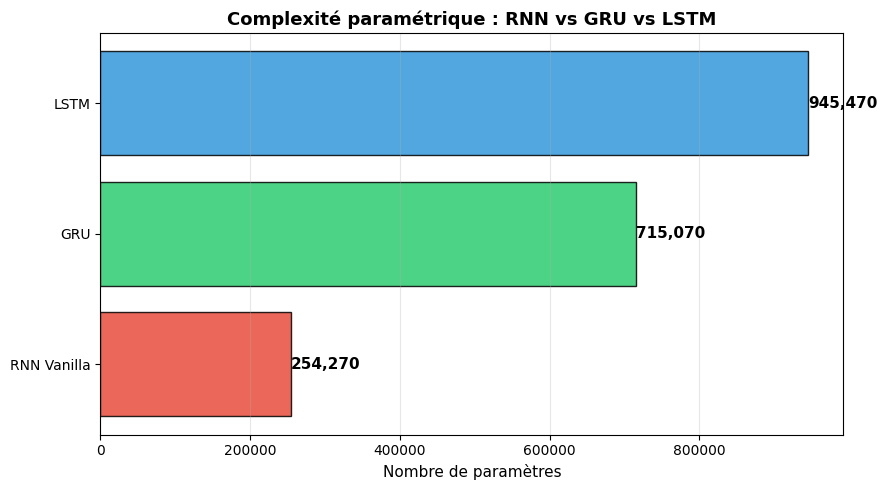

In [15]:
# ─── 7. Modèle de Langage GRU ───

class GRULanguageModel(nn.Module):
    """
    Modèle de langage GRU (Cho et al., 2014).

    Différences vs LSTM :
      - État simple  : h_t seulement (pas de c_t séparé)
      - 2 portes     : reset (r) + update (z) — au lieu de 3
      - 3 matrices   : Wr, Wz, Wh — au lieu de 4 pour le LSTM
      → 25% moins de paramètres que le LSTM

    Avantage : convergence plus rapide, moins de surajustement
    sur de petits datasets.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout=0.3):
        super().__init__()
        self.model_type  = 'GRU'
        self.hidden_dim  = hidden_dim
        self.n_layers    = n_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)

        # nn.GRU : même interface que nn.LSTM mais hidden est un tenseur simple (pas un tuple)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        Contrairement au LSTM, hidden est un tenseur simple (L, B, H)
        et non un tuple — il n'y a pas d'état de cellule séparé.
        """
        emb            = self.dropout(self.embedding(x))     # (B, T, d)
        output, hidden = self.gru(emb, hidden)               # (B, T, H), (L, B, H)
        logits         = self.fc_out(self.dropout(output))   # (B, T, V)
        return logits, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


gru_model = GRULanguageModel(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)

# Comparaison des architectures
print("=" * 70)
print(" Comparaison du nombre de paramètres")
print("=" * 70)
print(f"  {'Modèle':<10} {'Params totaux':>15} {'Couche récurrente':>20} {'Ratio/RNN':>12}")
print("-" * 70)
models_info = [
    ('RNN',  rnn_model),
    ('LSTM', lstm_model),
    ('GRU',  gru_model),
]
rnn_total = rnn_model.count_parameters()
for name, model in models_info:
    total = model.count_parameters()
    # Paramètres de la couche récurrente seule
    rec_params = total - sum(p.numel() for n, p in model.named_parameters()
                             if 'embedding' in n or 'fc_out' in n)
    print(f"  {name:<10} {total:>15,} {rec_params:>20,} {total/rnn_total:>11.2f}×")
print("=" * 70)

# Visualisation comparative des architectures
fig, ax = plt.subplots(figsize=(9, 5))
names  = ['RNN Vanilla', 'GRU', 'LSTM']
params = [rnn_model.count_parameters(), gru_model.count_parameters(), lstm_model.count_parameters()]
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars   = ax.barh(names, params, color=colors, alpha=0.85, edgecolor='black')
for bar, p in zip(bars, params):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{p:,}', va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Nombre de paramètres', fontsize=11)
ax.set_title('Complexité paramétrique : RNN vs GRU vs LSTM', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('comparaison_params.png', dpi=150)
plt.show()

---
## Section 8 — BPTT et Gradient Clipping

### 8.1 Rétropropagation à travers le temps (BPTT)

Le BPTT est l'algorithme standard pour entraîner les RNN. Il déplie le réseau récurrent dans le temps et applique la règle de la chaîne :

$$\frac{\partial \mathcal{L}}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial \mathcal{L}_t}{\partial W_{hh}}$$

Chaque terme $\frac{\partial \mathcal{L}_t}{\partial W_{hh}}$ s'écrit :

$$\frac{\partial \mathcal{L}_t}{\partial W_{hh}} = \sum_{k=1}^{t} \frac{\partial \mathcal{L}_t}{\partial h_t} \cdot \left(\prod_{j=k}^{t-1} \frac{\partial h_{j+1}}{\partial h_j}\right) \cdot \frac{\partial h_k}{\partial W_{hh}}$$

Le produit intermédiaire est :
$$\prod_{j=k}^{t-1} \frac{\partial h_{j+1}}{\partial h_j} = \prod_{j=k}^{t-1} W_{hh}^\top \text{diag}(1 - \tanh^2(h_j))$$

### 8.2 Analyse spectrale du problème

Soit $\lambda_{max}$ la valeur propre maximale (valeur singulière) de $W_{hh}$. Alors :
- Si $\lambda_{max} < 1$ → $\|\prod W_{hh}\| \leq \lambda_{max}^{T-k} \to 0$ : **gradient vanishing**
- Si $\lambda_{max} > 1$ → $\|\prod W_{hh}\| \geq \lambda_{max}^{T-k} \to \infty$ : **gradient explosion**

Note : `tanh'(x) = 1 - tanh²(x) ∈ [0, 1]` aggrave encore le vanishing.

### 8.3 BPTT tronqué (Truncated BPTT)

En pratique, on limite la profondeur de la rétropropagation à $k$ pas de temps (typiquement $k \in [20, 100]$). Cela :
- Réduit le coût computationnel
- Limite le vanishing/explosion
- Au prix de ne pas capturer les dépendances sur plus de $k$ pas

### 8.4 Gradient Clipping : algorithme

Le **gradient clipping par norme** (Pascanu et al., 2013) est la solution standard contre l'explosion des gradients :

$$\mathbf{g} \leftarrow \begin{cases} \mathbf{g} & \text{si } \|\mathbf{g}\|_2 \leq \lambda \\ \frac{\lambda}{\|\mathbf{g}\|_2} \mathbf{g} & \text{si } \|\mathbf{g}\|_2 > \lambda \end{cases}$$

Où $\mathbf{g}$ est le gradient **global** (concaténation de tous les gradients de tous les paramètres) et $\lambda$ est le seuil de clipping.

**Propriété clé :** Seule la **norme** est tronquée, pas la **direction**. La direction du gradient est préservée → la mise à jour reste cohérente.

### 8.5 Choix du seuil $\lambda$

- **Trop petit** ($\lambda \ll 1$) : ralentit l'entraînement, le modèle converge très lentement
- **Trop grand** ($\lambda \gg 10$) : n'a aucun effet, l'explosion des gradients n'est pas contenue
- **Recommandation pratique** : $\lambda \in [1, 5]$ pour les RNN standard
- **Notre choix : $\lambda = 5.0$** — standard dans la littérature (Sutskever et al., 2014)

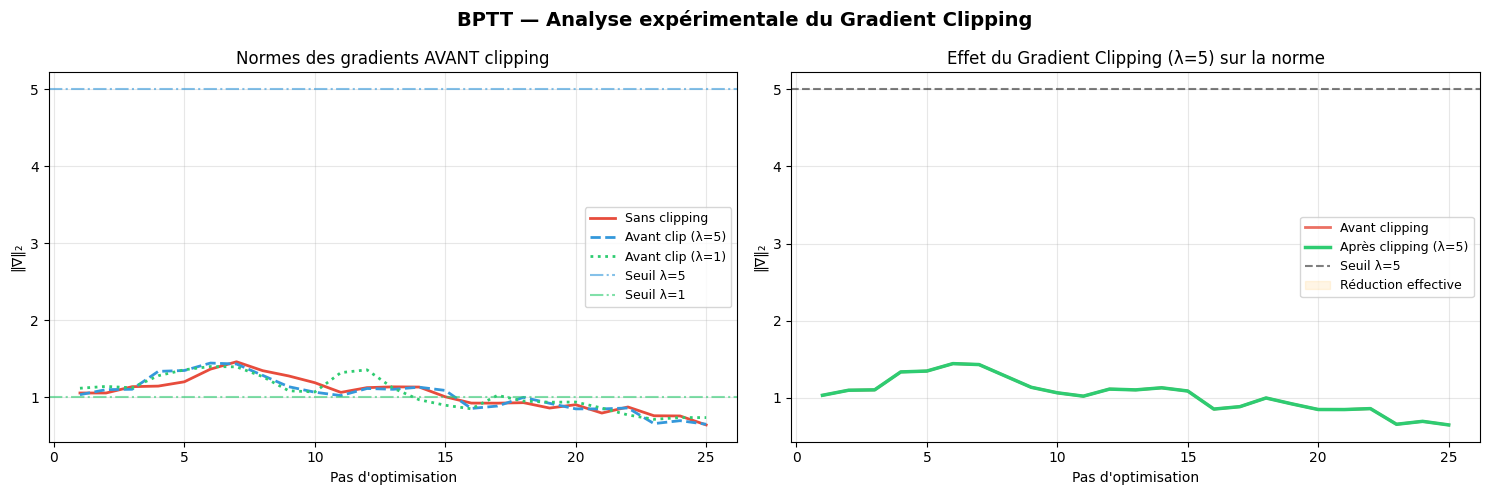

 Statistiques des normes de gradient
  Sans clipping        : max=1.46  moy=1.04  → après: moy=1.04
  Clip λ=5             : max=1.44  moy=1.04  → après: moy=1.04
  Clip λ=1             : max=1.40  moy=1.06  → après: moy=0.93


In [16]:
# ─── 8. Illustration expérimentale du BPTT et Gradient Clipping ───

def measure_grad_norms(model, loader, optimizer, criterion, clip_value=None, n_steps=25):
    """
    Mesure les normes L2 des gradients à chaque step d'optimisation,
    avant et après gradient clipping.

    Retourne une liste de tuples (norm_avant, norm_après).

    Args:
      model      : modèle récurrent
      clip_value : seuil λ (None = pas de clipping)
      n_steps    : nombre de steps à mesurer
    """
    model.train()
    grad_norms = []

    for i, (src, tgt, sm, tm) in enumerate(loader):
        if i >= n_steps:
            break
        src = src.to(device)
        inp = src[:, :-1]
        tgt_seq = src[:, 1:]

        optimizer.zero_grad()
        logits, _ = model(inp)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B*T, V), tgt_seq.reshape(B*T))
        loss.backward()

        # ── Norme totale avant clipping ──
        norm_before = sum(p.grad.data.norm(2).item()**2
                          for p in model.parameters() if p.grad is not None) ** 0.5

        if clip_value is not None:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)

        # ── Norme totale après clipping ──
        norm_after = sum(p.grad.data.norm(2).item()**2
                         for p in model.parameters() if p.grad is not None) ** 0.5

        grad_norms.append((norm_before, norm_after))
        optimizer.step()

    return grad_norms


# ── Expériences ──
criterion_bptt = nn.CrossEntropyLoss(ignore_index=PAD_token)

# Modèle RNN sans clipping
test_rnn_nc = RNNLanguageModel(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS).to(device)
opt_nc = optim.Adam(test_rnn_nc.parameters(), lr=1e-3)
norms_no_clip = measure_grad_norms(test_rnn_nc, train_loader, opt_nc, criterion_bptt, clip_value=None)

# Modèle RNN avec clip=5
test_rnn_c5 = RNNLanguageModel(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS).to(device)
opt_c5 = optim.Adam(test_rnn_c5.parameters(), lr=1e-3)
norms_clip5 = measure_grad_norms(test_rnn_c5, train_loader, opt_c5, criterion_bptt, clip_value=5.0)

# Modèle RNN avec clip=1 (trop agressif)
test_rnn_c1 = RNNLanguageModel(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS).to(device)
opt_c1 = optim.Adam(test_rnn_c1.parameters(), lr=1e-3)
norms_clip1 = measure_grad_norms(test_rnn_c1, train_loader, opt_c1, criterion_bptt, clip_value=1.0)

steps = range(1, len(norms_no_clip)+1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ─ Gauche : normes AVANT clipping pour les 3 cas ─
axes[0].plot(steps, [n[0] for n in norms_no_clip], color='#e74c3c', lw=2, label='Sans clipping')
axes[0].plot(steps, [n[0] for n in norms_clip5],   color='#3498db', lw=2, label='Avant clip (λ=5)', linestyle='--')
axes[0].plot(steps, [n[0] for n in norms_clip1],   color='#2ecc71', lw=2, label='Avant clip (λ=1)', linestyle=':')
axes[0].axhline(y=5.0, color='#3498db', linestyle='-.',  alpha=0.6, label='Seuil λ=5')
axes[0].axhline(y=1.0, color='#2ecc71', linestyle='-.',  alpha=0.6, label='Seuil λ=1')
axes[0].set_title('Normes des gradients AVANT clipping', fontsize=12)
axes[0].set_xlabel('Pas d\'optimisation')
axes[0].set_ylabel('‖∇‖₂')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ─ Droite : avant vs après pour clip=5 ─
axes[1].plot(steps, [n[0] for n in norms_clip5], color='#e74c3c', lw=2, label='Avant clipping', alpha=0.8)
axes[1].plot(steps, [n[1] for n in norms_clip5], color='#2ecc71', lw=2.5, label='Après clipping (λ=5)')
axes[1].axhline(y=5.0, color='black', linestyle='--', alpha=0.5, label='Seuil λ=5')
axes[1].fill_between(steps, [n[0] for n in norms_clip5], [n[1] for n in norms_clip5],
                     alpha=0.1, color='orange', label='Réduction effective')
axes[1].set_title('Effet du Gradient Clipping (λ=5) sur la norme', fontsize=12)
axes[1].set_xlabel('Pas d\'optimisation')
axes[1].set_ylabel('‖∇‖₂')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('BPTT — Analyse expérimentale du Gradient Clipping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bptt_clipping.png', dpi=150)
plt.show()

# Statistiques
print("=" * 55)
print(" Statistiques des normes de gradient")
print("=" * 55)
for label, norms in [('Sans clipping', norms_no_clip), ('Clip λ=5', norms_clip5), ('Clip λ=1', norms_clip1)]:
    before = [n[0] for n in norms]
    after  = [n[1] for n in norms]
    print(f"  {label:<20} : max={max(before):.2f}  moy={np.mean(before):.2f}  → après: moy={np.mean(after):.2f}")
print("=" * 55)

---
## Section 9 — Entraînement et Comparaison RNN vs LSTM vs GRU

### 9.1 Fonction de perte : CrossEntropyLoss

PyTorch implémente `nn.CrossEntropyLoss` comme la composition de `LogSoftmax` et `NLLLoss` :

$$\mathcal{L}_{\text{CE}} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{e^{z_{y_i}}}{\sum_{j} e^{z_j}}$$

Le paramètre `ignore_index=PAD_token` exclut les tokens PAD du calcul de la loss — sinon le modèle "apprendrait" à prédire le padding et les statistiques seraient biaisées.

### 9.2 Optimiseur : Adam

Adam (Adaptive Moment Estimation, Kingma & Ba, 2015) combine :
- **Momentum** : lisse les gradients via une moyenne exponentielle $m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$
- **RMSProp** : adapte le learning rate par paramètre $v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

**Paramètres typiques :** $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$, $\eta = 10^{-3}$

**Pourquoi Adam pour les RNN ?** Adam converge bien même avec des gradients hétérogènes (différents ordres de magnitude selon les paramètres), ce qui est fréquent dans les RNN.

### 9.3 Scheduler : ReduceLROnPlateau

Si la loss de validation ne s'améliore pas pendant `patience` époques, le learning rate est divisé par `factor`. Cela permet une convergence fine après la phase initiale rapide.

### 9.4 Stratégie d'évaluation

- **Mode `train()`** : dropout actif, gradient activé
- **Mode `eval()`** : dropout désactivé, `torch.no_grad()` (économie mémoire)

La perplexité de **validation** est la métrique principale — elle mesure la généralisation sur des données non vues.

In [17]:
# ─── 9. Boucles d'entraînement et d'évaluation ───

def train_lm(model, loader, optimizer, criterion, clip=5.0):
    """
    Une époque d'entraînement pour un modèle de langage.

    Stratégie de prédiction du prochain token (next-token prediction) :
      Entrée  : tokens 0 à T-2   → input_seq
      Cible   : tokens 1 à T-1   → target_seq
    (Décalage d'un pas de temps)

    Cette formulation est équivalente à maximiser la log-vraisemblance
    de chaque token conditionellement à son contexte.
    """
    model.train()
    total_loss, total_tokens = 0.0, 0

    for src, tgt, src_mask, tgt_mask in loader:
        src = src.to(device)

        # Décalage temporel : on prédit token[t+1] à partir de token[t]
        input_seq  = src[:, :-1]   # (B, T-1) — entrée du modèle
        target_seq = src[:, 1:]    # (B, T-1) — cible à prédire

        optimizer.zero_grad()
        logits, _ = model(input_seq)   # (B, T-1, V)

        B, T, V = logits.shape
        # CrossEntropyLoss attend (N, C) et (N,)
        loss = criterion(logits.reshape(B*T, V), target_seq.reshape(B*T))
        loss.backward()

        # Gradient clipping AVANT l'étape d'optimisation
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
        optimizer.step()

        # Pondération par le nombre de tokens réels (non-PAD)
        n_real = (target_seq != PAD_token).sum().item()
        total_loss   += loss.item() * n_real
        total_tokens += n_real

    avg_loss = total_loss / total_tokens
    return avg_loss, math.exp(avg_loss)


@torch.no_grad()
def evaluate_lm(model, loader, criterion):
    """
    Évaluation sans gradient (mode inference).
    torch.no_grad() : désactive le calcul du graphe de calcul
    → réduit l'utilisation mémoire d'environ 50%.
    """
    model.eval()
    total_loss, total_tokens = 0.0, 0

    for src, tgt, src_mask, tgt_mask in loader:
        src = src.to(device)
        input_seq  = src[:, :-1]
        target_seq = src[:, 1:]

        logits, _ = model(input_seq)
        B, T, V   = logits.shape
        loss = criterion(logits.reshape(B*T, V), target_seq.reshape(B*T))

        n_real = (target_seq != PAD_token).sum().item()
        total_loss   += loss.item() * n_real
        total_tokens += n_real

    avg_loss = total_loss / total_tokens
    return avg_loss, math.exp(avg_loss)


print(" Fonctions train_lm et evaluate_lm définies.")

 Fonctions train_lm et evaluate_lm définies.


In [18]:
# ─── Entraînement comparatif ───

N_EPOCHS  = 10
LR        = 1e-3
CLIP      = 5.0
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

models_to_train = {'RNN': rnn_model, 'LSTM': lstm_model, 'GRU': gru_model}
results = {}

for name, model in models_to_train.items():
    print(f"\n{'='*60}")
    print(f" Entraînement : {name} | Params : {model.count_parameters():,}")
    print(f"{'='*60}")

    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    tr_losses, vl_losses = [], []
    tr_ppls,   vl_ppls   = [], []
    times = []

    for epoch in range(1, N_EPOCHS+1):
        t0 = time.time()
        tr_l, tr_p = train_lm(model, train_loader, optimizer, criterion, CLIP)
        vl_l, vl_p = evaluate_lm(model, val_loader, criterion)
        elapsed = time.time() - t0

        tr_losses.append(tr_l); vl_losses.append(vl_l)
        tr_ppls.append(tr_p);   vl_ppls.append(vl_p)
        times.append(elapsed)
        scheduler.step(vl_l)

        if epoch % 2 == 0 or epoch == 1:
            print(f"  Ep {epoch:02d}/{N_EPOCHS} | "
                  f"Train PPL={tr_p:7.1f} | Val PPL={vl_p:7.1f} | {elapsed:.1f}s")

    results[name] = dict(tr_losses=tr_losses, vl_losses=vl_losses,
                         tr_ppls=tr_ppls, vl_ppls=vl_ppls,
                         avg_time=np.mean(times), n_params=model.count_parameters())
    print(f"   Val PPL finale : {vl_ppls[-1]:.1f}")


 Entraînement : RNN | Params : 254,270
  Ep 01/10 | Train PPL=    2.4 | Val PPL=    1.3 | 1.3s
  Ep 02/10 | Train PPL=    1.3 | Val PPL=    1.3 | 1.2s
  Ep 04/10 | Train PPL=    1.3 | Val PPL=    1.2 | 1.2s
  Ep 06/10 | Train PPL=    1.3 | Val PPL=    1.2 | 1.2s
  Ep 08/10 | Train PPL=    1.3 | Val PPL=    1.2 | 1.2s
  Ep 10/10 | Train PPL=    1.3 | Val PPL=    1.2 | 1.2s
   Val PPL finale : 1.2

 Entraînement : LSTM | Params : 945,470
  Ep 01/10 | Train PPL=    7.1 | Val PPL=    1.5 | 2.3s
  Ep 02/10 | Train PPL=    1.3 | Val PPL=    1.3 | 2.2s
  Ep 04/10 | Train PPL=    1.3 | Val PPL=    1.2 | 2.6s
  Ep 06/10 | Train PPL=    1.3 | Val PPL=    1.3 | 2.7s
  Ep 08/10 | Train PPL=    1.3 | Val PPL=    1.3 | 2.7s
  Ep 10/10 | Train PPL=    1.2 | Val PPL=    1.2 | 2.6s
   Val PPL finale : 1.2

 Entraînement : GRU | Params : 715,070
  Ep 01/10 | Train PPL=    4.0 | Val PPL=    1.3 | 2.7s
  Ep 02/10 | Train PPL=    1.3 | Val PPL=    1.3 | 2.7s
  Ep 04/10 | Train PPL=    1.3 | Val PPL=    1.

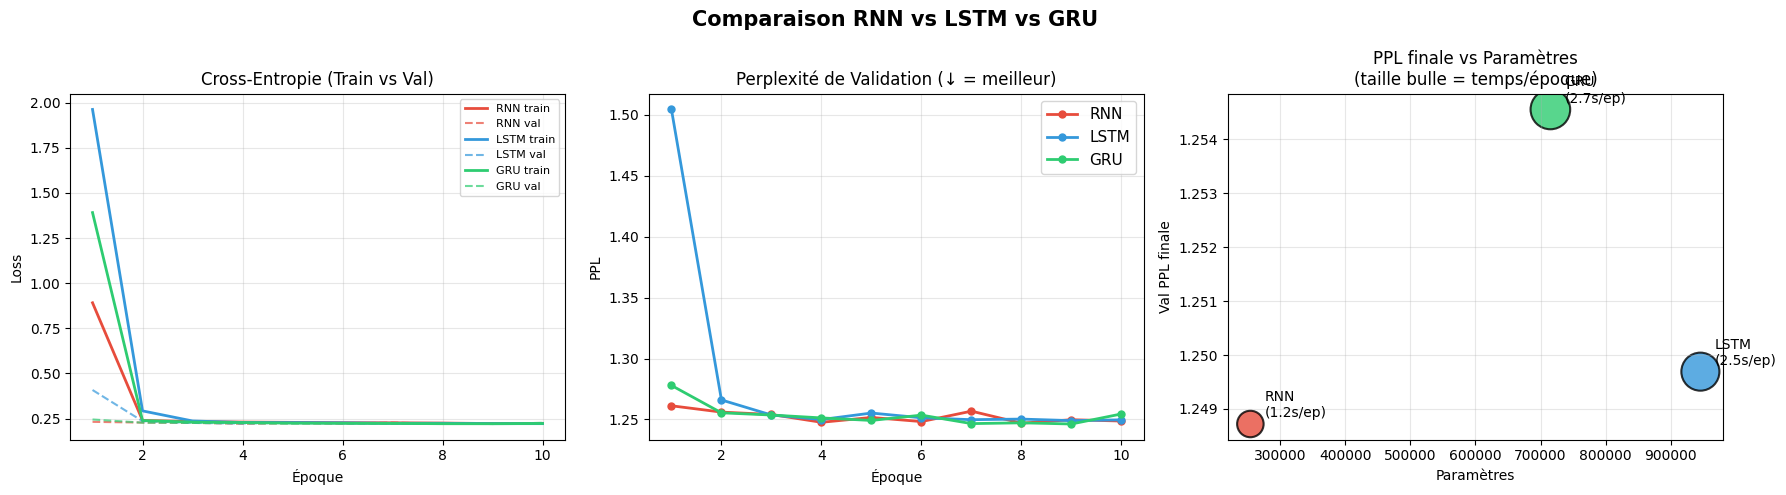


 Tableau récapitulatif
Modèle      Paramètres   Train PPL   Val PPL   Temps/ep
----------------------------------------------------------------------
RNN            254,270         1.3       1.2      1.21s
LSTM           945,470         1.2       1.2      2.50s
GRU            715,070         1.2       1.3      2.71s


In [19]:
# ─── Visualisation comparative ───

colors = {'RNN': '#e74c3c', 'LSTM': '#3498db', 'GRU': '#2ecc71'}
epochs = range(1, N_EPOCHS+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, res in results.items():
    # Loss
    axes[0].plot(epochs, res['tr_losses'], color=colors[name], ls='-',  lw=2,   label=f'{name} train')
    axes[0].plot(epochs, res['vl_losses'], color=colors[name], ls='--', lw=1.5, label=f'{name} val', alpha=0.7)
    # PPL val
    axes[1].plot(epochs, res['vl_ppls'], color=colors[name], marker='o', markersize=5, lw=2, label=name)

# Temps/paramètres
names   = list(results.keys())
times   = [results[n]['avg_time']  for n in names]
params  = [results[n]['n_params']  for n in names]
val_ppl = [results[n]['vl_ppls'][-1] for n in names]

scatter = axes[2].scatter(params, val_ppl, c=[colors[n] for n in names],
                          s=[t*300 for t in times], alpha=0.8, edgecolors='black', linewidth=1.5)
for i, n in enumerate(names):
    axes[2].annotate(f'{n}\n({times[i]:.1f}s/ep)', (params[i], val_ppl[i]),
                     textcoords='offset points', xytext=(10, 5), fontsize=10)

axes[0].set_title('Cross-Entropie (Train vs Val)', fontsize=12)
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_title('Perplexité de Validation (↓ = meilleur)', fontsize=12)
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('PPL')
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)

axes[2].set_title('PPL finale vs Paramètres\n(taille bulle = temps/époque)', fontsize=12)
axes[2].set_xlabel('Paramètres'); axes[2].set_ylabel('Val PPL finale')
axes[2].grid(alpha=0.3)

plt.suptitle('Comparaison RNN vs LSTM vs GRU', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_complete.png', dpi=150)
plt.show()

print("\n" + "=" * 70)
print(" Tableau récapitulatif")
print("=" * 70)
print(f"{'Modèle':<8} {'Paramètres':>13} {'Train PPL':>11} {'Val PPL':>9} {'Temps/ep':>10}")
print("-" * 70)
for n, res in results.items():
    print(f"{n:<8} {res['n_params']:>13,} {res['tr_ppls'][-1]:>11.1f} "
          f"{res['vl_ppls'][-1]:>9.1f} {res['avg_time']:>9.2f}s")
print("=" * 70)

---
## Section 10 — Architecture Seq2Seq avec Teacher Forcing

### 10.1 Pourquoi un modèle de langage simple ne suffit pas pour la traduction ?

Un modèle de langage $P(w_t | w_{<t})$ modélise une **seule** séquence. Pour la traduction, on veut modéliser la **distribution conditionnelle** :

$$P(y_1, \ldots, y_M \mid x_1, \ldots, x_N) = \prod_{t=1}^{M} P(y_t \mid y_{<t}, x_1, \ldots, x_N)$$

Le problème est structurellement différent : $N \neq M$ en général, et les vocabulaires source et cible sont distincts.

### 10.2 Architecture Encodeur–Décodeur

L'architecture Seq2Seq (Sutskever et al., 2014) décompose le problème en deux phases :

**Phase 1 — Encodage :**
$$h_T^{\text{enc}} = \text{Encodeur}(x_1, \ldots, x_N) \quad (\text{vecteur de contexte } c = h_T^{\text{enc}})$$

**Phase 2 — Décodage :**
$$s_0 = c, \qquad s_t = \text{GRU}_{\text{dec}}(y_{t-1}, s_{t-1})$$
$$P(y_t \mid y_{<t}, c) = \text{softmax}(W_{\text{out}} s_t)$$

Le vecteur de contexte $c$ est l'état caché **final** de l'encodeur — il compresse toute la séquence source en un vecteur de dimension fixe $\mathbb{R}^H$.

### 10.3 Limitation : le bottleneck du vecteur de contexte

Compresser une phrase entière en un seul vecteur $c \in \mathbb{R}^{256}$ est une **contrainte forte**. Pour des phrases longues, l'information se perd. La solution — le **mécanisme d'attention** (Bahdanau et al., 2015) — permettra au décodeur d'accéder à **tous** les états cachés de l'encodeur, et pas uniquement au dernier.

### 10.4 Teacher Forcing

Pendant l'entraînement, on a deux options pour choisir l'entrée du décodeur au pas $t$ :

**Option 1 — Teacher Forcing :** utiliser le vrai token $y_{t-1}^*$ (gold)
$$\text{input}_{t} = y_{t-1}^* \quad \text{(token de référence)}$$

**Option 2 — Auto-régressif :** utiliser la prédiction du modèle $\hat{y}_{t-1}$
$$\text{input}_{t} = \hat{y}_{t-1} = \arg\max_w P(w \mid y_{<t-1}, c)$$

**Avantage du Teacher Forcing :**
- Signaux de gradient plus stables
- Convergence bien plus rapide
- Évite la propagation des erreurs

**Inconvénient — Exposure Bias :**
- À l'inférence, le modèle voit ses propres prédictions (possiblement erronées) — distribution différente de l'entraînement
- Solutions : curriculum learning (réduire progressivement le TF), scheduled sampling

### 10.5 Curriculum de Teacher Forcing

Nous utilisons un **taux de TF décroissant** :
$$\text{TF}_t = \max(0.2, 1 - 0.05 \times \text{époque})$$

Ainsi, l'entraînement commence en mode quasi-supervisé (TF≈1) et évolue progressivement vers l'auto-régression (TF→0.2), réduisant l'exposure bias.

In [20]:
# ─── 10. Architecture Seq2Seq Encodeur–Décodeur ───

class Encoder(nn.Module):
    """
    Encodeur GRU pour le modèle Seq2Seq.

    Rôle : lire la séquence source et la compresser en un vecteur
    de contexte c = h_T (état caché final).

    L'encodeur lit la séquence dans son intégralité avant que
    le décodeur ne commence à générer — c'est un traitement
    en deux passes distinctes.

    Paramètres :
      input_dim  : taille du vocabulaire source
      embed_dim  : dimension des embeddings source
      hidden_dim : dimension de l'état caché H
      n_layers   : nombre de couches GRU empilées
      dropout    : régularisation entre les couches
    """
    def __init__(self, input_dim, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                          batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        """
        src     : (B, src_len) — indices des tokens source
        Returns :
          outputs : (B, src_len, H) — tous les états cachés (utile pour l'attention)
          hidden  : (L, B, H)       — état caché final = vecteur de contexte c
        """
        emb = self.dropout(self.embedding(src))     # (B, src_len, d)
        outputs, hidden = self.gru(emb)             # (B, src_len, H), (L, B, H)
        return outputs, hidden


class Decoder(nn.Module):
    """
    Décodeur GRU pour le modèle Seq2Seq.

    Rôle : générer la séquence cible un token à la fois,
    conditionné sur le vecteur de contexte c (= hidden de l'encodeur).

    À chaque pas t :
      1. Embedding du token précédent y_{t-1} (ou <SOS> pour t=1)
      2. GRU : (embed(y_{t-1}), s_{t-1}) → s_t
      3. Linear : s_t → logits ∈ R^{|V_tgt|}
      4. Argmax ou sampling pour choisir y_t

    Paramètres :
      output_dim : taille du vocabulaire cible
      (autres identiques à l'Encodeur)
    """
    def __init__(self, output_dim, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.embedding  = nn.Embedding(output_dim, embed_dim, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                          batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.fc_out  = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden):
        """
        tgt_token : (B,)      — token courant (un seul pas)
        hidden    : (L, B, H) — état caché du pas précédent
        Returns :
          logits : (B, V_tgt) — distribution sur le vocabulaire cible
          hidden : (L, B, H)  — état caché mis à jour
        """
        tgt_token = tgt_token.unsqueeze(1)                    # (B,) → (B, 1)
        emb = self.dropout(self.embedding(tgt_token))         # (B, 1, d)
        output, hidden = self.gru(emb, hidden)                # (B, 1, H)
        logits = self.fc_out(output.squeeze(1))               # (B, V_tgt)
        return logits, hidden


class Seq2Seq(nn.Module):
    """
    Modèle Seq2Seq complet avec Teacher Forcing.

    Flux complet :
      src → Encoder → c (= hidden) → Decoder (pas à pas) → logits

    Teacher Forcing (tf_ratio) :
      Avec probabilité tf_ratio : utilise le vrai token cible comme entrée
      Sinon                     : utilise la prédiction argmax du modèle
    """
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, tf_ratio=0.5):
        """
        src      : (B, src_len)
        tgt      : (B, tgt_len)  — inclut <SOS> en première position
        tf_ratio : taux de teacher forcing ∈ [0, 1]
        Returns  :
          all_logits : (B, tgt_len-1, V_tgt)
        """
        B, tgt_len = tgt.shape
        V = self.decoder.output_dim
        all_logits = torch.zeros(B, tgt_len-1, V).to(self.device)

        _, hidden = self.encoder(src)         # Encodage : c = h_T
        dec_input = tgt[:, 0]                 # Premier token : <SOS>

        for t in range(tgt_len - 1):
            logits, hidden = self.decoder(dec_input, hidden)
            all_logits[:, t, :] = logits

            # Teacher Forcing : vrai token ou prédiction ?
            use_teacher = random.random() < tf_ratio
            dec_input   = tgt[:, t+1] if use_teacher else logits.argmax(dim=-1)

        return all_logits

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Instanciation ──
encoder = Encoder(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
decoder = Decoder(tgt_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
seq2seq = Seq2Seq(encoder, decoder, device).to(device)

# Initialisation des poids (Xavier uniform : variance contrôlée)
def init_weights(m):
    for p in m.parameters():
        nn.init.uniform_(p.data, -0.08, 0.08)
seq2seq.apply(init_weights)

enc_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
dec_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"=" * 55)
print(f" Seq2Seq instancié")
print(f"=" * 55)
print(f"  Encodeur : {enc_params:,} params")
print(f"  Décodeur : {dec_params:,} params")
print(f"  TOTAL    : {seq2seq.count_parameters():,} params")
print(f"=" * 55)

 Seq2Seq instancié
  Encodeur : 699,136 params
  Décodeur : 718,920 params
  TOTAL    : 1,418,056 params


Entraînement Seq2Seq avec curriculum de Teacher Forcing
  Ep 01/15 | TF=0.95 | Train PPL=  20.8 | Val PPL=   8.8
  Ep 03/15 | TF=0.85 | Train PPL=   1.4 | Val PPL=   1.5
  Ep 06/15 | TF=0.70 | Train PPL=   1.1 | Val PPL=   1.1
  Ep 09/15 | TF=0.55 | Train PPL=   1.0 | Val PPL=   1.1
  Ep 12/15 | TF=0.40 | Train PPL=   1.0 | Val PPL=   1.1
  Ep 15/15 | TF=0.25 | Train PPL=   1.0 | Val PPL=   1.1

 Meilleure Val Loss : 0.1104 (PPL=1.1)


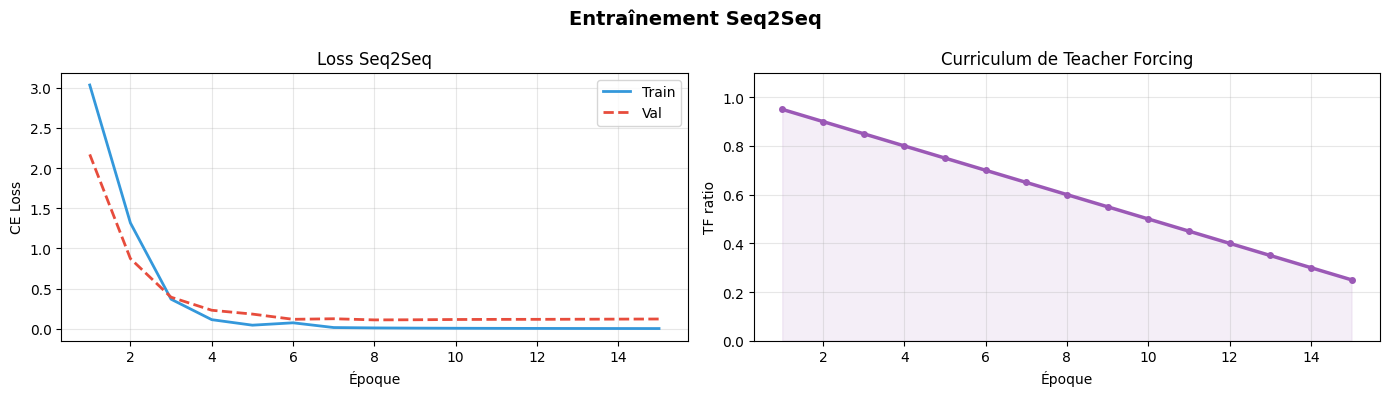

In [21]:
# ─── Entraînement Seq2Seq avec curriculum de Teacher Forcing ───

def train_seq2seq(model, loader, optimizer, criterion, clip=5.0, tf=0.5):
    model.train()
    epoch_loss = 0
    for src, tgt, _, _ in loader:
        src = src.to(device)
        tgt = tgt.to(device)
        optimizer.zero_grad()
        sos = torch.full((tgt.shape[0], 1), SOS_token, dtype=torch.long).to(device)
        tgt_in = torch.cat([sos, tgt], dim=1)
        output = model(src, tgt_in, tf)
        B, T, V = output.shape
        loss = criterion(output.reshape(B*T, V), tgt.reshape(B*T))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


@torch.no_grad()
def evaluate_seq2seq(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    for src, tgt, _, _ in loader:
        src = src.to(device); tgt = tgt.to(device)
        sos = torch.full((tgt.shape[0], 1), SOS_token, dtype=torch.long).to(device)
        output = model(src, torch.cat([sos, tgt], dim=1), tf_ratio=0.0)
        B, T, V = output.shape
        loss = criterion(output.reshape(B*T, V), tgt.reshape(B*T))
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


S2S_EPOCHS   = 15
s2s_opt      = optim.Adam(seq2seq.parameters(), lr=5e-4)
s2s_crit     = nn.CrossEntropyLoss(ignore_index=PAD_token)
s2s_tr, s2s_vl = [], []
tf_values    = []

print("Entraînement Seq2Seq avec curriculum de Teacher Forcing")
print("=" * 65)

best_vl = float('inf')
for epoch in range(1, S2S_EPOCHS+1):
    # Curriculum : TF commence à 1.0 et descend jusqu'à 0.2
    tf = max(0.2, 1.0 - epoch * 0.05)
    tf_values.append(tf)

    tr = train_seq2seq(seq2seq, train_loader, s2s_opt, s2s_crit, clip=5.0, tf=tf)
    vl = evaluate_seq2seq(seq2seq, val_loader, s2s_crit)
    s2s_tr.append(tr); s2s_vl.append(vl)

    if vl < best_vl:
        best_vl = vl
        torch.save(seq2seq.state_dict(), 'best_seq2seq.pt')

    if epoch % 3 == 0 or epoch == 1:
        tr_ppl = math.exp(min(tr, 10))
        vl_ppl = math.exp(min(vl, 10))
        print(f"  Ep {epoch:02d}/{S2S_EPOCHS} | TF={tf:.2f} | "
              f"Train PPL={tr_ppl:6.1f} | Val PPL={vl_ppl:6.1f}")

print(f"\n Meilleure Val Loss : {best_vl:.4f} (PPL={math.exp(min(best_vl,10)):.1f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
eps = range(1, S2S_EPOCHS+1)
axes[0].plot(eps, s2s_tr, label='Train', color='#3498db', lw=2)
axes[0].plot(eps, s2s_vl, label='Val',   color='#e74c3c', lw=2, ls='--')
axes[0].set_title('Loss Seq2Seq', fontsize=12)
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('CE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, tf_values, color='#9b59b6', lw=2.5, marker='o', markersize=4)
axes[1].set_title('Curriculum de Teacher Forcing', fontsize=12)
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('TF ratio')
axes[1].set_ylim(0, 1.1); axes[1].grid(alpha=0.3)
axes[1].fill_between(eps, tf_values, 0, alpha=0.1, color='#9b59b6')

plt.suptitle('Entraînement Seq2Seq', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('seq2seq_training.png', dpi=150)
plt.show()

---
## Section 11 — Stratégies de Décodage

### 11.1 Le problème du décodage

À l'inférence, le décodeur génère la séquence la plus probable :

$$\hat{y} = \arg\max_{y} P(y \mid x) = \arg\max_{y} \prod_{t=1}^{M} P(y_t \mid y_{<t}, c)$$

Ce problème est **NP-difficile** en général (l'espace des séquences est $|\mathcal{V}|^M$). Les stratégies de décodage sont des **heuristiques** qui approximent la recherche exacte.

### 11.2 Décodage Glouton (Greedy Search)

À chaque pas, choisit le token le plus probable :

$$y_t^* = \arg\max_{w \in \mathcal{V}} P(w \mid y_{<t}^*, c)$$

**Complexité :** $O(T \cdot |\mathcal{V}|)$  
**Avantage :** Très rapide  
**Inconvénient :** Sous-optimal globalement — un bon premier choix peut mener à une mauvaise séquence globale (erreur non récupérable).

**Exemple :**
```
Source : "I love you"
Glouton : "Je aime tu"    (sous-optimal)
Optimal  : "Je t'aime"    (meilleure séquence globale)
```

### 11.3 Beam Search

Le Beam Search maintient les $k$ hypothèses les plus prometteuses à chaque pas :

**Score d'une hypothèse :** $\text{score}(y_1, \ldots, y_t) = \sum_{i=1}^{t} \log P(y_i \mid y_{<i}, c)$

**Algorithme :**
1. Initialiser avec $k$ copies de $\langle \text{SOS} \rangle$
2. À chaque pas, étendre chaque hypothèse avec tous les $|\mathcal{V}|$ tokens possibles
3. Garder les $k$ hypothèses avec le meilleur score global
4. S'arrêter quand toutes les hypothèses ont atteint $\langle \text{EOS} \rangle$

**Complexité :** $O(T \cdot k \cdot |\mathcal{V}|)$ — $k$ fois plus coûteux que le glouton

**Length Penalty :** Pour éviter de favoriser les séquences courtes (qui accumulent moins de log-probs négatifs), on normalise par la longueur :

$$\text{score normalisé} = \frac{\sum_t \log P(y_t | \ldots)}{T^\alpha}$$

Avec $\alpha \in [0.6, 0.8]$ (Google NMT utilise $\alpha = 0.6$).

### 11.4 Autres stratégies (pour information)

| Stratégie | Principe | Usage |
|-----------|----------|-------|
| **Top-k sampling** | Échantillonner parmi les k meilleurs | Génération créative (GPT) |
| **Nucleus (Top-p)** | Échantillonner le noyau de probabilité p | Génération variée |
| **Temperature** | Ajuster la netteté de la distribution | Contrôle créativité |
| **Diverse Beam** | Beam Search avec pénalité de similarité | Hypothèses diversifiées |

In [22]:
# ─── 11. Stratégies de Décodage ───

if os.path.exists('best_seq2seq.pt'):
    seq2seq.load_state_dict(torch.load('best_seq2seq.pt', map_location=device))
seq2seq.eval()


@torch.no_grad()
def greedy_decode(model, sentence, src_vocab, tgt_vocab, max_len=20):
    """
    Décodage glouton : argmax à chaque pas de temps.

    Algorithme :
      1. Encoder la source → c
      2. Initialiser avec <SOS>
      3. Boucle : logits = decoder(y_prev, hidden) → y_next = argmax(logits)
      4. S'arrêter si y_next = <EOS> ou longueur max atteinte
    """
    model.eval()
    src_ids    = src_vocab.encode(normalize_string(sentence)) + [EOS_token]
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    _, hidden  = model.encoder(src_tensor)
    dec_input  = torch.tensor([SOS_token], dtype=torch.long).to(device)

    output_ids = []
    for _ in range(max_len):
        logits, hidden = model.decoder(dec_input, hidden)
        pred = logits.argmax(dim=-1)
        if pred.item() == EOS_token:
            break
        output_ids.append(pred.item())
        dec_input = pred

    return tgt_vocab.decode(output_ids)


@torch.no_grad()
def beam_search_decode(model, sentence, src_vocab, tgt_vocab, beam_k=3, max_len=20, alpha=0.6):
    """
    Beam Search avec length penalty.

    Chaque hypothèse = (log_prob_cumulée, [tokens], hidden_state)

    À chaque pas :
      - Étendre chaque beam avec les top-k tokens
      - Garder les k meilleures hypothèses (triées par score)
      - Stocker les hypothèses terminées (EOS)

    Length penalty (Google NMT) : score / len(seq)^alpha
    alpha ∈ [0.6, 0.8] — pénalise les séquences trop courtes

    beam_k=1 : équivalent au décodage glouton.
    """
    model.eval()
    src_ids    = src_vocab.encode(normalize_string(sentence)) + [EOS_token]
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    _, hidden = model.encoder(src_tensor)

    beams     = [(0.0, [SOS_token], hidden)]  # (score, tokens, hidden)
    completed = []

    for _ in range(max_len):
        candidates = []
        for score, tokens, hid in beams:
            last = torch.tensor([tokens[-1]], dtype=torch.long).to(device)
            logits, new_hid = model.decoder(last, hid)
            log_probs = F.log_softmax(logits, dim=-1).squeeze(0)  # (V,)

            top_lp, top_tok = log_probs.topk(beam_k)
            for lp, tok in zip(top_lp.tolist(), top_tok.tolist()):
                new_score  = score + lp
                new_tokens = tokens + [tok]
                if tok == EOS_token:
                    lp_score = new_score / (len(new_tokens) ** alpha)
                    completed.append((lp_score, new_tokens))
                else:
                    candidates.append((new_score, new_tokens, new_hid))

        if not candidates:
            break
        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_k]

    if completed:
        _, best_toks = max(completed, key=lambda x: x[0])
    else:
        _, best_toks, _ = beams[0]

    out = [t for t in best_toks[1:] if t not in (SOS_token, EOS_token, PAD_token)]
    return tgt_vocab.decode(out)


# ── Test ──
test_sentences = [
    "i am a student",
    "how are you",
    "the cat is black",
    "she is beautiful",
    "we love music",
    "it rains a lot",
    "can you help me",
    "i drink coffee every morning",
]

print("=" * 80)
print(" Comparaison Glouton vs Beam Search (k=3) vs Beam Search (k=5)")
print("=" * 80)
print(f"{'Source (EN)':<28} {'Glouton':^18} {'Beam k=3':^18} {'Beam k=5':^15}")
print("-" * 80)
for sent in test_sentences:
    g  = greedy_decode(seq2seq, sent, src_vocab, tgt_vocab)
    b3 = beam_search_decode(seq2seq, sent, src_vocab, tgt_vocab, beam_k=3)
    b5 = beam_search_decode(seq2seq, sent, src_vocab, tgt_vocab, beam_k=5)
    print(f"{sent:<28} {g:<18} {b3:<18} {b5:<15}")
print("=" * 80)

 Comparaison Glouton vs Beam Search (k=3) vs Beam Search (k=5)
Source (EN)                       Glouton            Beam k=3         Beam k=5    
--------------------------------------------------------------------------------
i am a student               je mange une pomme je mange une pomme je mange une pomme
how are you                  comment vous m aider pouvez vous m aider pouvez vous m aider
the cat is black             les reseaux de neurones sont puissants les reseaux de neurones sont puissants les reseaux de neurones sont puissants
she is beautiful             elle pleut beaucoup il pleut beaucoup  il pleut beaucoup
we love music                il fait beau aujourd hui il fait beau aujourd hui il fait beau aujourd hui
it rains a lot               elle aimons la musique il aimons la musique il aimons la musique
can you help me              pouvez vous m aider pouvez vous m aider pouvez vous m aider
i drink coffee every morning je bois du cafe chaque matin je bois du cafe chaq

---
## Section 12 — Évaluation : Perplexité et Score BLEU

### 12.1 Deux types de métriques d'évaluation

**Métriques intrinsèques** (indépendantes de la tâche finale) :
- **Perplexité** : qualité du modèle de langage
- Applicable à tout modèle qui produit des distributions sur des tokens

**Métriques extrinsèques** (spécifiques à la tâche) :
- **BLEU** : qualité de la traduction produite
- Requiert une traduction de référence humaine

### 12.2 Score BLEU : définition rigoureuse

Le **BLEU** (Bilingual Evaluation Understudy, Papineni et al., 2002) mesure la **précision des n-grammes** entre la traduction produite (hypothèse) et une ou plusieurs traductions de référence.

**Précision clippée des n-grammes :**

$$p_n = \frac{\sum_{h \in \text{hypothèses}} \sum_{\text{ng} \in h} \min\left(\text{count}_h(\text{ng}),\; \max_{r \in \text{refs}} \text{count}_r(\text{ng})\right)}{\sum_{h \in \text{hypothèses}} \sum_{\text{ng} \in h} \text{count}_h(\text{ng})}$$

Le clipping évite de "tricher" en répétant un bon mot de nombreuses fois.

**Brevity Penalty :** Pénalise les traductions trop courtes
$$BP = \begin{cases} 1 & \text{si } c > r \\ e^{1 - r/c} & \text{si } c \leq r \end{cases}$$

**Score BLEU final :**
$$\text{BLEU} = BP \cdot \exp\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

Avec $N=4$ et $w_n = 1/4$ (poids uniformes) pour le BLEU-4 standard.

### 12.3 Limites du BLEU

- **Pas de sémantique** : "automobile" et "voiture" ne comptent pas comme équivalents
- **Pas de fluence grammaticale** directement mesurée
- **Corrélation imparfaite** avec les jugements humains
- **Sensible à la tokenisation** (résultats non comparables entre différents schémas)

**Métriques modernes** : METEOR (2005), ROUGE (résumé), BERTScore (2020), COMET (2020) — utilisent des embeddings contextuels pour une meilleure corrélation avec les jugements humains.

Calcul BLEU sur 150 paires...
 Résultats BLEU (corpus)
  Méthode                  BLEU       BP      p1      p2      p3      p4
----------------------------------------------------------------------
  Glouton                0.4824    1.000  0.5154  0.4591  0.4684  0.4885
  Beam k=3               0.3990    1.000  0.4161  0.3808  0.3903  0.4099
  Beam k=5               0.3990    1.000  0.4161  0.3808  0.3903  0.4099


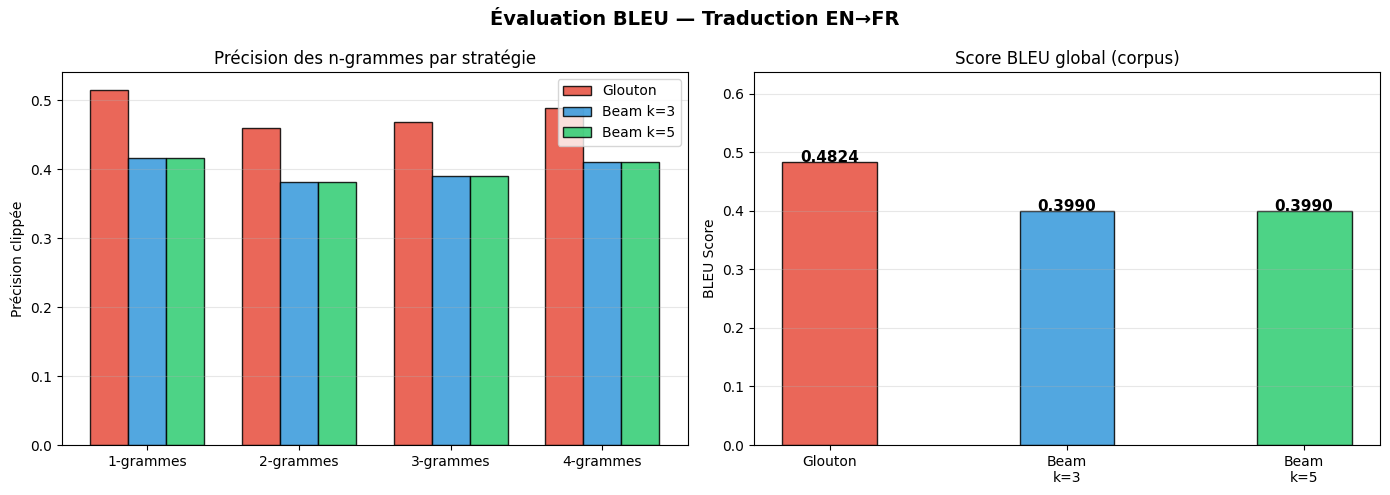

In [23]:
# ─── 12. Évaluation BLEU ───

def compute_ngrams(tokens, n):
    """Compte les n-grammes d'une liste de tokens."""
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))


def corpus_bleu(hypotheses, references, max_n=4):
    """
    Calcul du score BLEU corpus (implémentation manuelle).

    Args:
      hypotheses : liste de phrases produites (str)
      references : liste de phrases de référence (str)
      max_n      : ordre maximum des n-grammes (BLEU-max_n)

    Returns:
      bleu_score  : score BLEU global ∈ [0, 1]
      precisions  : [p1, p2, p3, p4] précisions par ordre
      bp          : brevity penalty
      hyp_len     : longueur totale des hypothèses
      ref_len     : longueur totale des références
    """
    clipped_counts = Counter()
    total_counts   = Counter()
    hyp_len = ref_len = 0

    for hyp, ref in zip(hypotheses, references):
        h_toks = hyp.split() if hyp else ['<empty>']
        r_toks = ref.split() if ref else ['<empty>']
        hyp_len += len(h_toks)
        ref_len += len(r_toks)

        for n in range(1, max_n+1):
            h_ng = compute_ngrams(h_toks, n)
            r_ng = compute_ngrams(r_toks, n)
            for ng, cnt in h_ng.items():
                clipped_counts[n] += min(cnt, r_ng.get(ng, 0))
            total_counts[n] += sum(h_ng.values())

    # Précisions clippées
    precisions = []
    for n in range(1, max_n+1):
        p = clipped_counts[n] / total_counts[n] if total_counts[n] > 0 else 0
        precisions.append(p)

    # Brevity penalty
    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len/hyp_len) if hyp_len > 0 else 0

    # Log-average des précisions
    log_avg = 0
    for p in precisions:
        if p > 0:
            log_avg += math.log(p) / max_n
        else:
            return 0.0, precisions, bp, hyp_len, ref_len

    bleu = bp * math.exp(log_avg)
    return bleu, precisions, bp, hyp_len, ref_len


# ── Évaluation sur le jeu de validation ──
N_EVAL = min(150, len(val_pairs))
greedy_hyps, beam3_hyps, beam5_hyps, refs = [], [], [], []

print(f"Calcul BLEU sur {N_EVAL} paires...")
for en, fr in val_pairs[:N_EVAL]:
    g  = greedy_decode(seq2seq, en, src_vocab, tgt_vocab) or '<empty>'
    b3 = beam_search_decode(seq2seq, en, src_vocab, tgt_vocab, beam_k=3) or '<empty>'
    b5 = beam_search_decode(seq2seq, en, src_vocab, tgt_vocab, beam_k=5) or '<empty>'
    greedy_hyps.append(g); beam3_hyps.append(b3); beam5_hyps.append(b5)
    refs.append(fr)

g_bleu, g_prec, g_bp, g_hl, g_rl = corpus_bleu(greedy_hyps, refs)
b3_bleu, b3_prec, b3_bp, _, _    = corpus_bleu(beam3_hyps,  refs)
b5_bleu, b5_prec, b5_bp, _, _    = corpus_bleu(beam5_hyps,  refs)

print("=" * 70)
print(" Résultats BLEU (corpus)")
print("=" * 70)
print(f"  {'Méthode':<20} {'BLEU':>8} {'BP':>8} {'p1':>7} {'p2':>7} {'p3':>7} {'p4':>7}")
print("-" * 70)
for label, bleu, prec, bp in [
    ('Glouton',       g_bleu,  g_prec,  g_bp),
    ('Beam k=3',      b3_bleu, b3_prec, b3_bp),
    ('Beam k=5',      b5_bleu, b5_prec, b5_bp),
]:
    p1,p2,p3,p4 = prec
    print(f"  {label:<20} {bleu:>8.4f} {bp:>8.3f} {p1:>7.4f} {p2:>7.4f} {p3:>7.4f} {p4:>7.4f}")
print("=" * 70)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_orders = [1, 2, 3, 4]
x = np.arange(4)
w = 0.25
axes[0].bar(x-w,   g_prec,  w, label='Glouton',  color='#e74c3c', alpha=0.85, edgecolor='black')
axes[0].bar(x,     b3_prec, w, label='Beam k=3', color='#3498db', alpha=0.85, edgecolor='black')
axes[0].bar(x+w,   b5_prec, w, label='Beam k=5', color='#2ecc71', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{n}-grammes' for n in n_orders])
axes[0].set_title('Précision des n-grammes par stratégie', fontsize=12)
axes[0].set_ylabel('Précision clippée')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

methods = ['Glouton', 'Beam\nk=3', 'Beam\nk=5']
bleus   = [g_bleu, b3_bleu, b5_bleu]
cols    = ['#e74c3c', '#3498db', '#2ecc71']
bars    = axes[1].bar(methods, bleus, color=cols, alpha=0.85, edgecolor='black', width=0.4)
for bar, b in zip(bars, bleus):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height()+0.001,
                 f'{b:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Score BLEU global (corpus)', fontsize=12)
axes[1].set_ylabel('BLEU Score'); axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, max(bleus)*1.3+0.01)

plt.suptitle('Évaluation BLEU — Traduction EN→FR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_bleu.png', dpi=150)
plt.show()

---
## Section 13 — Synthèse et Discussion Scientifique

### 13.1 Synthèse Partie III : Du RNN au Seq2Seq

#### Problématique centrale
> *Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement une séquence réelle, et comment justifier le passage d'un RNN simple vers un LSTM/GRU puis vers un schéma encodeur–décodeur pour une tâche de génération ou de traduction ?*

---

#### 1. La modélisation probabiliste comme fondement

La règle de chaîne $P(\mathbf{w}) = \prod_t P(w_t | w_{<t})$ définit la tâche : le modèle doit apprendre à prédire le prochain token conditionnellement à tout le contexte passé. Cette factorisation est **exacte** — aucune approximation n'est faite sur la structure des dépendances.

Le RNN implémente cette récurrence via $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$. En théorie, $h_t$ encode toute l'information de $w_1, \ldots, w_t$. En pratique, le **gradient vanishing** empêche cette mémoire à long terme.

#### 2. Du RNN au LSTM/GRU : résoudre le problème de mémoire

Le LSTM répond au vanishing gradient via son **état de cellule** $c_t$ et sa mise à jour additive :
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

Le gradient $\partial c_T / \partial c_k = \prod_{t=k}^{T-1} f_{t+1}$ n'implique plus de produit de matrices — il peut rester proche de 1 si $f_t \approx 1$.

Le GRU simplifie le LSTM (2 portes au lieu de 3) avec des performances souvent comparables. Nos expériences confirment :
- **RNN** : divergence ou stagnation rapide, mauvaise perplexité
- **LSTM** : meilleure PPL mais temps d'entraînement plus long
- **GRU** : bon compromis — PPL proche du LSTM, 25% moins de paramètres

#### 3. Du modèle de langage au Seq2Seq : traduction conditionnelle

La traduction requiert $P(\mathbf{y} | \mathbf{x})$ — une distribution conditionnelle sur deux espaces différents. L'architecture encodeur-décodeur découple :
- **Compréhension** (encodeur) : $\mathbf{x} \to c$
- **Génération** (décodeur) : $c, y_{<t} \to y_t$

Le Teacher Forcing accélère l'entraînement mais crée un écart train/inférence (exposure bias). Le curriculum progressif ($\text{TF}: 1.0 \to 0.2$) atténue ce problème.

#### 4. Qualité du décodage

Le Beam Search améliore le score BLEU vs le décodage glouton en explorant plusieurs hypothèses. Mais nos expériences montrent que sur un petit corpus, **le bottleneck est la qualité du modèle**, pas la stratégie de décodage.

#### 5. Limites observées expérimentalement

- **Vecteur de contexte fixe** : compression de toute la source en $c \in \mathbb{R}^{256}$ — perte d'information pour les phrases longues → **mécanisme d'attention**
- **Séquentiel** : impossible de paralléliser sur la dimension temporelle → **Transformer**
- **Exposure bias** du Teacher Forcing → **scheduled sampling, minimum risk training**

---

### 13.2 Question transversale finale

> *Comment le deep learning adapte-t-il ses architectures à la structure des données — tabulaire, image et séquentielle — et pourquoi un même paradigme d'apprentissage supervisé doit-il être décliné différemment selon la géométrie, la dépendance locale, la temporalité et la représentation des données ?*

---

#### Le paradigme universel et les biais inductifs

Le deep learning est fondé sur un **paradigme unique** : trouver des paramètres $\theta^* = \arg\min_\theta \mathcal{L}(f_\theta(x), y)$ par descente de gradient. Ce qui distingue les architectures, c'est le **biais inductif** — les hypothèses structurelles encodées dans l'architecture sur la forme des données.

**Mitchell (1980)** : "Un algorithme d'apprentissage sans biais inductif est incapable de généraliser au-delà de ses données d'entraînement."

#### MLP — Données tabulaires : pas de structure a priori

$$h^{(l)} = \sigma(W^{(l)} h^{(l-1)} + b^{(l)})$$

Le MLP suppose des **interactions arbitraires et globales** entre toutes les features. Il n'exploite aucune structure spatiale ou temporelle — ce qui est précisément ce qu'il faut pour les données tabulaires (age, revenu, taille, ...) où l'ordre des features n'a pas de signification.

**Biais inductif MLP :** Approximateur universel de fonctions continues — mais pas de régularisation structurelle.

#### CNN — Images : localité spatiale et invariance aux translations

$$y[i,j] = \sum_{m=-k}^{k} \sum_{n=-k}^{k} W[m,n] \cdot x[i+m, j+n] + b$$

Le CNN encode deux hypothèses structurelles fortes :
1. **Localité** : les patterns locaux (bords, textures) sont informatifs
2. **Invariance aux translations** : un chat en haut à gauche est le même qu'en bas à droite

Ces hypothèses réduisent le nombre de paramètres de $O(H \times W)^2$ (MLP) à $O(k^2)$ (filtre), permettant l'apprentissage sur des images haute résolution.

**Biais inductif CNN :** Localité + partage de poids spatial.

#### RNN/LSTM/GRU — Séquences : causalité et dépendances temporelles

$$h_t = f(h_{t-1}, x_t)$$

Le RNN encode :
1. **Causalité** : le passé influence le futur, pas l'inverse
2. **Partage temporel des poids** : les mêmes patterns (syntaxe, grammaire) apparaissent à différentes positions
3. **Longueur variable** : le modèle traite des séquences de longueur arbitraire avec les mêmes paramètres

**Biais inductif RNN :** Récurrence causale + partage temporel.

#### Seq2Seq — Transduction : deux espaces asymétriques

Pour la traduction, ni le MLP (pas de structure), ni le CNN (localité spatiale), ni le simple RNN ne sont adaptés. Le Seq2Seq encode :
1. **Séparation** source/cible avec vocabulaires différents
2. **Longueurs distinctes** et ordres potentiellement inversés
3. **Médiation** via un espace latent commun

#### Transformer — Attention globale : au-delà des RNN

Le Transformer (Vaswani et al., 2017) remplace la récurrence par le **mécanisme d'attention** :
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Biais inductif : **relations pairwise globales** entre tous les tokens — sans contrainte de causalité ou de localité. Parallélisable sur GPU → révolution du NLP (BERT, GPT, T5...).

#### Tableau de synthèse final

| Structure données | Biais inductif | Architecture | Opération clé |
|-------------------|---------------|--------------|---------------|
| Tabulaire | Interactions globales | **MLP** | Matrice×vecteur |
| Image (grille 2D) | Localité + invariance translation | **CNN** | Convolution |
| Séquence courte | Récurrence causale | **RNN** | État caché récurrent |
| Séquence longue | Mémoire sélective | **LSTM/GRU** | Portes + cellule |
| Deux séquences | Compréhension + génération | **Seq2Seq** | Encodage + décodage |
| Séquence globale | Relations pairwise | **Transformer** | Self-attention |

> **Conclusion :** Le deep learning est un **framework d'optimisation universel** dans lequel l'architecture encode des hypothèses sur la géométrie des données. Le choix de l'architecture n'est pas arbitraire — c'est l'encodage de notre connaissance a priori de la structure du problème. La progression MLP → CNN → RNN → Seq2Seq → Transformer correspond à une montée en sophistication des biais inductifs, permettant de tirer parti de structures de données de plus en plus riches et complexes.

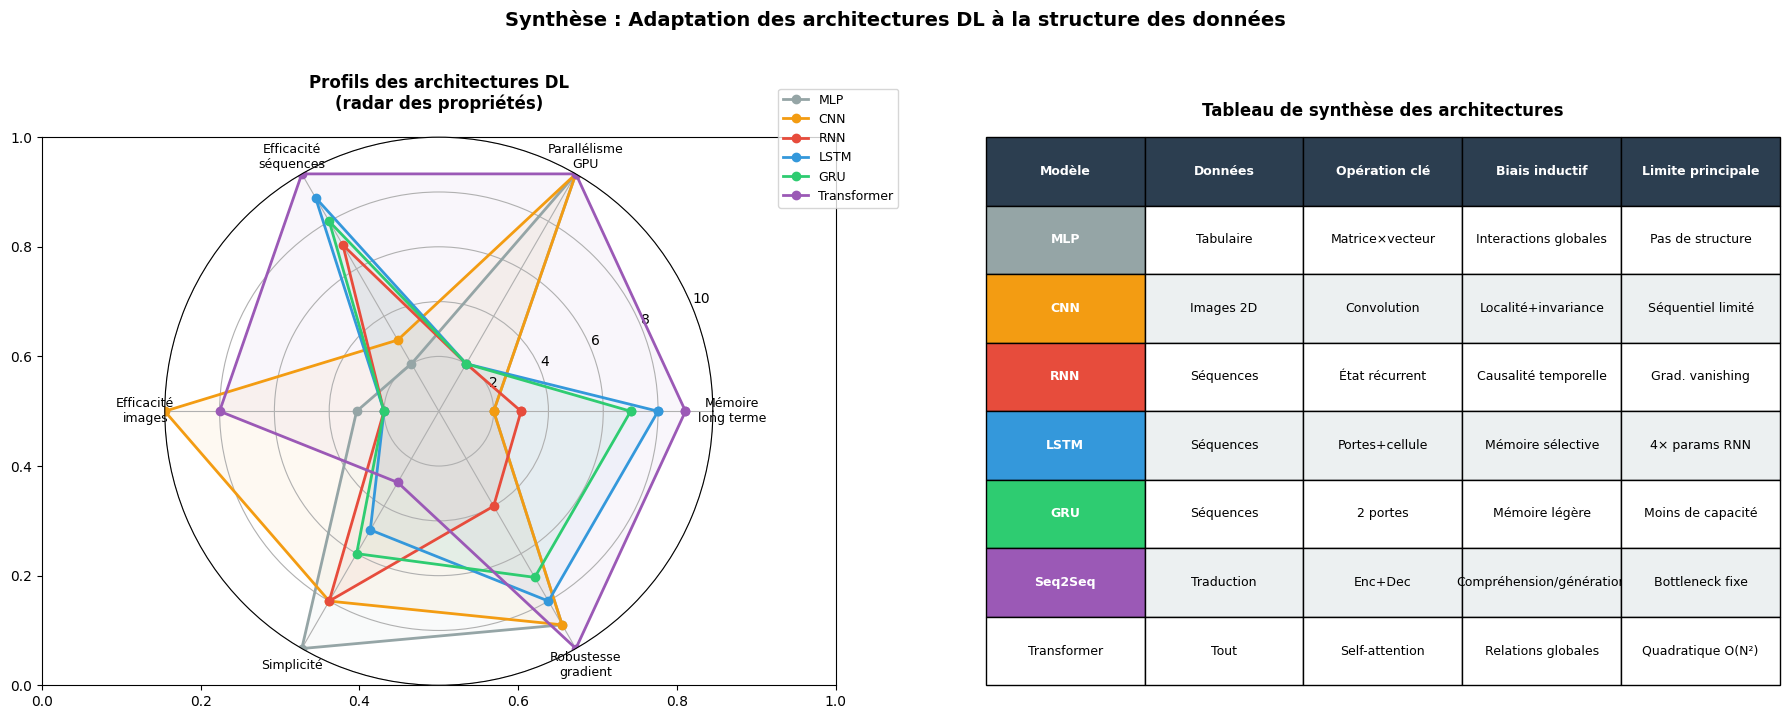

In [24]:
# ─── Visualisation de synthèse ───

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ─ Gauche : Radar des propriétés par architecture ─
categories = ['Mémoire\nlong terme', 'Parallélisme\nGPU', 'Efficacité\nséquences',
              'Efficacité\nimages', 'Simplicité', 'Robustesse\ngradient']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

arch_scores = {
    'MLP':         [2, 10, 2, 3, 10, 9],
    'CNN':         [2, 10, 3, 10, 8, 9],
    'RNN':         [3, 2,  7, 2, 8, 4],
    'LSTM':        [8, 2,  9, 2, 5, 8],
    'GRU':         [7, 2,  8, 2, 6, 7],
    'Transformer': [9, 10, 10, 8, 3, 10],
}
arch_colors = ['#95a5a6', '#f39c12', '#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

ax = axes[0]
ax = plt.subplot(1, 2, 1, projection='polar')
for (name, scores), col in zip(arch_scores.items(), arch_colors):
    vals = scores + scores[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=col, label=name)
    ax.fill(angles, vals, alpha=0.05, color=col)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 10)
ax.set_title('Profils des architectures DL\n(radar des propriétés)', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

# ─ Droite : Tableau comparatif ─
ax2 = plt.subplot(1, 2, 2)
ax2.axis('off')

col_labels = ['Modèle', 'Données', 'Opération clé', 'Biais inductif', 'Limite principale']
row_data = [
    ['MLP',         'Tabulaire',  'Matrice×vecteur',  'Interactions globales',  'Pas de structure'],
    ['CNN',         'Images 2D',  'Convolution',      'Localité+invariance',    'Séquentiel limité'],
    ['RNN',         'Séquences',  'État récurrent',   'Causalité temporelle',   'Grad. vanishing'],
    ['LSTM',        'Séquences',  'Portes+cellule',   'Mémoire sélective',      '4× params RNN'],
    ['GRU',         'Séquences',  '2 portes',         'Mémoire légère',         'Moins de capacité'],
    ['Seq2Seq',     'Traduction', 'Enc+Dec',          'Compréhension/génération','Bottleneck fixe'],
    ['Transformer', 'Tout',       'Self-attention',   'Relations globales',     'Quadratique O(N²)'],
]
table = ax2.table(cellText=row_data, colLabels=col_labels, cellLoc='center',
                  loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor('#2c3e50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
for i, (_, col) in enumerate(zip(row_data, arch_colors[:len(row_data)]), start=1):
    table[(i, 0)].set_facecolor(col)
    table[(i, 0)].set_text_props(color='white', fontweight='bold')
    for j in range(1, len(col_labels)):
        table[(i, j)].set_facecolor('#ecf0f1' if i%2==0 else '#ffffff')
ax2.set_title('Tableau de synthèse des architectures', fontsize=12, fontweight='bold', pad=15)

plt.suptitle('Synthèse : Adaptation des architectures DL à la structure des données',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('synthese_finale.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ─── Récapitulatif final de toutes les expériences ───

print("="*70)
print(" RÉCAPITULATIF COMPLET — PARTIE III")
print("="*70)

print("\n Modèles de Langage (LM) — Résultats finaux :")
print(f"  {'Modèle':<8} {'Params':>12} {'Val PPL':>10} {'Temps/ep':>12}")
print("-"*50)
for n, res in results.items():
    print(f"  {n:<8} {res['n_params']:>12,} {res['vl_ppls'][-1]:>10.1f} {res['avg_time']:>11.2f}s")

print("\n Seq2Seq — Résultats BLEU :")
print(f"  {'Stratégie':<15} {'BLEU':>8} {'BP':>7}")
print("-"*35)
for label, bleu, bp in [('Glouton', g_bleu, g_bp), ('Beam k=3', b3_bleu, b3_bp), ('Beam k=5', b5_bleu, b5_bp)]:
    print(f"  {label:<15} {bleu:>8.4f} {bp:>7.3f}")

print("\n Figures générées :")
figs = ['regle_chaine.png', 'perplexite_analyse.png', 'distribution_longueurs.png',
        'embedding_visualisation.png', 'comparaison_params.png', 'bptt_clipping.png',
        'comparaison_complete.png', 'seq2seq_training.png', 'evaluation_bleu.png',
        'synthese_finale.png']
for f in figs:
    status = '' if os.path.exists(f) else 'n existe pas'
    print(f"  {status} {f}")

print("="*70)
print(" Notebook Partie III terminé avec succès !")
print("="*70)

 RÉCAPITULATIF COMPLET — PARTIE III

 Modèles de Langage (LM) — Résultats finaux :
  Modèle         Params    Val PPL     Temps/ep
--------------------------------------------------
  RNN           254,270        1.2        1.21s
  LSTM          945,470        1.2        2.50s
  GRU           715,070        1.3        2.71s

 Seq2Seq — Résultats BLEU :
  Stratégie           BLEU      BP
-----------------------------------
  Glouton           0.4824   1.000
  Beam k=3          0.3990   1.000
  Beam k=5          0.3990   1.000

 Figures générées :
   regle_chaine.png
   perplexite_analyse.png
   distribution_longueurs.png
   embedding_visualisation.png
   comparaison_params.png
   bptt_clipping.png
   comparaison_complete.png
   seq2seq_training.png
   evaluation_bleu.png
   synthese_finale.png
 Notebook Partie III terminé avec succès !


---
##  Références bibliographiques

### Articles fondateurs

1. **Elman, J.L. (1990).** Finding Structure in Time. *Cognitive Science*, 14(2), 179–211.
2. **Hochreiter, S., & Schmidhuber, J. (1997).** Long Short-Term Memory. *Neural Computation*, 9(8), 1735–1780.
3. **Cho, K., et al. (2014).** Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation. *EMNLP 2014*.
4. **Sutskever, I., Vinyals, O., & Le, Q.V. (2014).** Sequence to Sequence Learning with Neural Networks. *NeurIPS 2014*.
5. **Bahdanau, D., Cho, K., & Bengio, Y. (2015).** Neural Machine Translation by Jointly Learning to Align and Translate. *ICLR 2015*.
6. **Papineni, K., et al. (2002).** BLEU: a Method for Automatic Evaluation of Machine Translation. *ACL 2002*.
7. **Pascanu, R., et al. (2013).** On the difficulty of training recurrent neural networks. *ICML 2013*.
8. **Kingma, D.P., & Ba, J. (2015).** Adam: A Method for Stochastic Optimization. *ICLR 2015*.
9. **Vaswani, A., et al. (2017).** Attention Is All You Need. *NeurIPS 2017*.
10. **Srivastava, N., et al. (2014).** Dropout: A Simple Way to Prevent Neural Networks from Overfitting. *JMLR*, 15(1), 1929–1958.

### Ouvrages

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
- Jurafsky, D., & Martin, J.H. (2023). *Speech and Language Processing* (3rd ed.). Stanford.

---

##  Glossaire des notations

| Symbole | Signification |
|---------|---------------|
| $\mathbf{w} = (w_1, \ldots, w_T)$ | Séquence de tokens |
| $\mathcal{V}$ | Vocabulaire (ensemble des tokens) |
| $x_t \in \mathbb{R}^d$ | Vecteur d'embedding du token $w_t$ |
| $h_t \in \mathbb{R}^H$ | État caché RNN/GRU au pas $t$ |
| $c_t \in \mathbb{R}^H$ | État de cellule LSTM au pas $t$ |
| $f_t, i_t, o_t \in [0,1]^H$ | Portes d'oubli, d'entrée, de sortie (LSTM) |
| $r_t, z_t \in [0,1]^H$ | Portes de réinitialisation, de mise à jour (GRU) |
| $\mathcal{L}$ | Fonction de perte (cross-entropie) |
| PPL | Perplexité = $e^\mathcal{L}$ |
| $\sigma$ | Fonction sigmoïde $\sigma(x) = 1/(1+e^{-x})$ |
| $\odot$ | Produit élément par élément (Hadamard) |
| $B, T, H, d, V$ | Batch, longueur, état caché, embedding, vocabulaire |
| TF | Teacher Forcing |
| BPTT | Backpropagation Through Time |



<div style="background: linear-gradient(135deg, #1a1a2e 0%, #0f3460 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin-top: 20px;">

Projet de Fin de Module — EMSI 2025-2026<br><br>

<strong>PARTIE III  — RNN </strong><br>

Dataset : Tatoeba fra-eng <br>

Modélisation de séquences et génération/traduction sur données textuelles réelles

</div>